# 03 - Überwachtes Lernen

# Überwachtes Lernen

Überwachtes Lernen ist ein Verfahren des maschinellen Lernens, bei dem ein Modell mit beschrifteten Daten trainiert wird. Das bedeutet, dass zu jedem Eingabewert die richtige Ausgabe bekannt ist. Das Modell lernt, Zusammenhänge zwischen Eingaben und Ausgaben zu erkennen, um später für neue, unbekannte Daten Vorhersagen zu treffen. Typische Anwendungsbeispiele sind die Klassifikation und die Regression.

Damit das Modell möglichst genaue Vorhersagen liefert, müssen seine Parameter während des Trainings geeignet angepasst werden. Hierzu wird zunächst mithilfe einer Fehler- bzw. Kostenfunktion bestimmt, wie stark die Modellvorhersagen von den tatsächlichen Zielwerten abweichen.

Zur Minimierung dieses Fehlers wird häufig das Verfahren des Gradientenabstiegs verwendet. Dabei werden die Modellparameter schrittweise in Richtung eines Minimums der Kostenfunktion angepasst. Die Berechnung der notwendigen Gradienten erfolgt insbesondere bei neuronalen Netzen mithilfe des Backpropagation-Algorithmus. Dieser bestimmt, wie stark einzelne Parameter zum Gesamtfehler beitragen, sodass die Gewichte des Modells gezielt optimiert werden können.

## Gradientenabstieg

In diesem Kapitel wird eine Vorübung durchgeführt. Sie dient dazu, das Verfahren des Gradientenabstiegs schrittweise zu verstehen und praktisch anzuwenden.

Vorgegeben ist das mathematische Modell $f$, welches für die Eingabe $\boldsymbol{x}$ das Ergebnis $y$ berechnet: $y=f(\boldsymbol{x})$. Das Modell hat eine Vielzahl von Modellparametern, z.B. Gewichte und Schwellwerte eines Perzeptrons. Für ein Perzeptron mit einer zweidimensionalen Eingabe $\boldsymbol{x} = \{x_1, x_2\}$ und der Aktivierungsfunktion $\phi(z) = \left(1+\exp(-z)\right)^{-1}$ (Sigmoid-Funktion) wird das Modell zu:

$$
y = \frac{1}{1+\exp(-(x_0\cdot w_0 + x_1\cdot w_1 + x_2\cdot w_2))} = f(\boldsymbol{x}, \boldsymbol{w} = \{w_0, w_1, w_2\})
$$

Dabei ist $z = \boldsymbol{x}\cdot \boldsymbol{w}$.

Das Ziel des überwachten Lernens ist die Modellparameter so zu bestimmen, dass die Modellfunktion die vorgegebenen Daten \(Trainingsdaten $\boldsymbol{\hat{x}}, \hat{y}$ \) möglichst gut repräsentiert.



### Abstandsfunktion

Um die Abweichung bzw. Abstand zwischen zwei Punktmengen, z.B. die Vorhersagen eines Modells $\left(o = f \left( \boldsymbol{x} \right) \right)$ und der Trainingszieldaten $\left( \hat{y} \right)$, zu bestimmen, kann beispielsweise folgende Fehlerfunktion $E$ mit der Loss-Funktion $J$ genutzt werden:

$$
E = \sum_i J(o,\hat{y}) \quad \text{mit} \quad J(o,\hat{y}) = \frac{1}{2}\left(o - \hat{y}\right)^2
$$

Das Ziel ist also die Werte der Modellparameter zu finden, welche die Fehlerfunktion $E = (\boldsymbol{w}; \boldsymbol{\hat{x}}, \hat{y})$ bei gegebenen Trainingsdatensatz minimieren. 

### Minimierung

Im Allgemeinen kann bei nicht-linearen Funktionen das Minimum nicht direkt bestimmt werden. Hier werden numerische Verfahren zum Minimierung verwendet. Ein häufig verwendetes Verfahren ist das [Gradientenverfahren](https://de.wikipedia.org/wiki/Gradientenverfahren). Das interative Verfahren nutzt den lokalen Wert des Gradienten der zu Minimierenden Funktion um die nächsten Iterationsschritte zu bestimmten. Für eine Funktion $G(\boldsymbol{x})$ sieht die Interation wie folgt aus:

$$
\boldsymbol{x}^{k+1} = \boldsymbol{x}^k +| \alpha \left.\left( \frac{\partial G}{\partial x_1}, \cdots, \frac{\partial G}{\partial x_n}\right)\right|_{\boldsymbol{x}^k}
$$

Dabei gibt der Parameter $\alpha$ die Schrittweite vor.

### Aufgabe 1: Implementierung des Gradientenverfahrens

Implementieren Sie in Python das obige Verfahren für die Funktion 

$$
G(\boldsymbol{x},y)
=
-2\,\exp\!\left(-\frac{(x-A_1)^2 + (y-B_1)^2}{D_1}\right)
-
\exp\!\left(-\frac{(x-A_2)^2 + (y-B_2)^2}{D_2}\right)
$$.

Dabei sind $A_1$,$B_1$ und $A_2$,$B_2$ die festen Zentren der beiden Gaußfunktionen. 
Die Parameter $D_1$ und $D_2$ bestimmen deren Breite.

In [1]:
#| include:false
import warnings
warnings.filterwarnings("ignore")

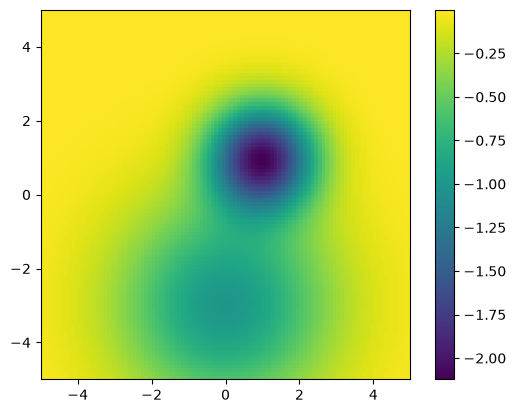

In [2]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

X,Y = np.meshgrid(x,y)

def my_f(x,y):
    A1 =  1.0
    B1 =  1.0
    A2 =  0.0
    B2 = -3.0
    D1 =  2.0
    D2 =  8.0


    return - 2*np.exp(-((x-A1)**2 + (y-B1)**2)/D1) - 1*np.exp(-((x-A2)**2 + (y-B2)**2)/D2)

def my_fp(x,y):
    A1 =  1.0
    B1 =  1.0
    A2 =  0.0
    B2 = -3.0
    D1 =  2.0
    D2 =  8.0

    fpx = -2*(x-A1)/D1 * (-2*np.exp(-((x-A1)**2 + (y-B1)**2)/D1)) + (-2*(x-A2)/D2 * (-1*np.exp(-((x-A2)**2 + (y-B2)**2)/D2)))
    fpy = -2*(y-B1)/D1 * (-2*np.exp(-((x-A1)**2 + (y-B1)**2)/D1)) + (-2*(y-B2)/D2 * (-1*np.exp(-((x-A2)**2 + (y-B2)**2)/D2)))

    return fpx, fpy
    
f = my_f(X,Y)

plt.imshow(f, extent=[-5, 5, -5, 5], origin='lower')
# plt.quiver(X, Y, *my_fp(X,Y), scale=20)

# plt.xlim([-3,3])
# plt.ylim([-3,3])

plt.colorbar()

Die Abbildung veranschaulicht den Verlauf des Gradientenabstiegs. Ausgehend von einem zufälligen Startwert werden die Modellparameter schrittweise angepasst, bis die Kostenfunktion minimiert wird.

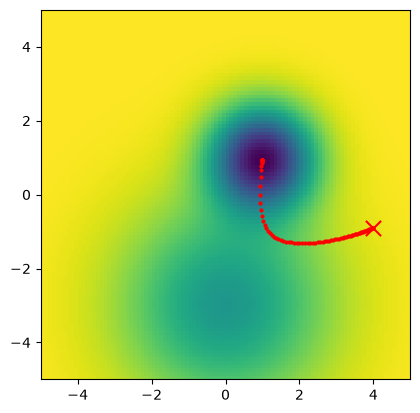

In [3]:
#| code-fold: true
#| code-summary: "Code anzeigen"

x0s = [4]
y0s = [-0.9]
alpha = 0.25

for i in range(100):
    cx = x0s[-1]
    cy = y0s[-1]
    dx, dy = my_fp(cx, cy)
    nx = cx - alpha*dx
    ny = cy - alpha*dy

    x0s.append(nx)
    y0s.append(ny)

plt.imshow(f, extent=[-5, 5, -5, 5], origin='lower')
plt.scatter(x0s[0], y0s[0], marker='x', s=120, c='red')
plt.plot(x0s, y0s, 'o', ms=2, color='red')

Die Abbildung zeigt die Entwicklung der Koordinaten x und y während des Optimierungsprozesses. In jedem Schritt werden die Parameter entlang des negativen Gradienten aktualisiert, sodass sich die Lösung schrittweise dem Minimum der Kostenfunktion annähert.

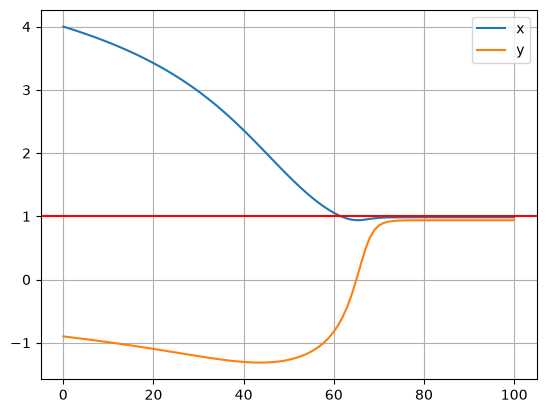

In [4]:
#| code-fold: true
#| code-summary: "Code anzeigen"

plt.plot(x0s, label='x')
plt.plot(y0s, label='y')

plt.axhline(y=1, color='red')

plt.grid()
plt.legend()

## Backpropagation -- Einzelnes Perzeptron

Bei dem Lernverfahren Backpropagation wird der Gradient der Fehlerfunktion (als Funktion der Gewichte und Schwellwerte) genutzt um die Minimierung durchzuführen. Dafür muss der Gradient für das Netzwerk bestimmt werden, welcher sich im allgemeinen aus einer Verschachtelung der Kettenregel für Ableitungen zusammensetzt. Bei der Verbindung von mehreren Perzeptronen / Neuronen zu einem Netzwerk, wird so effektiv bei diesem Verfahren das Netz rückwärts durchlaufen wodurch die Ausbreitung der Fehlerkorrektur von der Ausgabeschicht in die Eingabeschicht bewegt -- deshalb der Name 'Backpropagation'.

Für ein einzelnes Perzeptron mit einer linearen Aktivierungsfunktion $\phi(z) = z$ gilt für die Modellfunktion:

$$
y = f(\boldsymbol{x}) = \boldsymbol{x}\cdot\boldsymbol{w}
$$

und für die Fehlerfunktion:

$$
E = \frac{1}{2}\left(y - \hat{y}\right)^2 = \frac{1}{2}\left(\boldsymbol{\hat{x}}\cdot\boldsymbol{w} - \hat{y}\right)^2
$$

Die partielle Ableitung nach $w_1$ ist somit

$$
\frac{\partial E}{\partial w_1} = \hat{x}_1 \left( \boldsymbol{\hat{x}}\cdot\boldsymbol{w} - \hat{y}\right)
$$

Und der Gradient:

$$
\nabla E = \boldsymbol{\hat{x}} \left( \boldsymbol{\hat{x}}\cdot\boldsymbol{w} - \hat{y}\right)
$$

Im Folgenden wird das Verfahren Backpropagation an einem einzigen Datenpunkt demonstriert, welcher immer wieder durchlaufen wird. 

In jedem Schritt wird dabei der Abstand zwischen dem Output und dem Zielwert bestimmt und die Gewichte mit Gradientenabstieg angepasst. 

Die Gewichte konvergieren zur kleinsten Lösung.

In [5]:
#| code-fold: true
#| code-summary: "Code anzeigen"


# Perfect Match
# y = x1*3.4 + x2*0.7 - x3*2.3
Xtrain = [[1,2,3], [2,-3,4], [4,2,0]]
Ytrain = [3.4+1.4-6.9, 6.4-2.1-9.2, 13.6+1.4+0]

def forward(x, w):
    return np.dot(x,w)

ci = 2
cx = np.array([1] + Xtrain[ci])
cy = Ytrain[ci]

cw = np.zeros(4)

w_history = [cw]
alpha = 0.01
for i in range(20):
    cf = forward(cx, cw)
    print(cf, cf-cy, cw)

    cg = 2*cx*(np.dot(cx,cw) - cy)

    cw = cw - alpha*cg
    w_history.append(cw)
    
w_history = np.array(w_history)


0.0 -15.0 [0. 0. 0. 0.]
6.3 -8.7 [0.3 1.2 0.6 0. ]
9.954 -5.045999999999999 [0.474 1.896 0.948 0.   ]
12.073319999999999 -2.926680000000001 [0.57492 2.29968 1.14984 0.     ]
13.3025256 -1.6974744000000008 [0.6334536 2.5338144 1.2669072 0.       ]
14.015464847999999 -0.9845351520000012 [0.66740309 2.66961235 1.33480618 0.        ]
14.428969611839998 -0.5710303881600023 [0.68709379 2.74837516 1.37418758 0.        ]
14.6688023748672 -0.33119762513280016 [0.6985144 2.7940576 1.3970288 0.       ]
14.807905377422976 -0.1920946225770237 [0.70513835 2.82055341 1.4102767  0.        ]
14.888585118905326 -0.11141488109467446 [0.70898024 2.83592098 1.41796049 0.        ]
14.935379368965087 -0.06462063103491289 [0.71120854 2.84483417 1.42241708 0.        ]
14.962520033999752 -0.037479966000248055 [0.71250095 2.85000382 1.42500191 0.        ]
14.978261619719856 -0.021738380280144298 [0.71325055 2.85300221 1.42650111 0.        ]
14.987391739437516 -0.012608260562483764 [0.71368532 2.85474128 1.427370

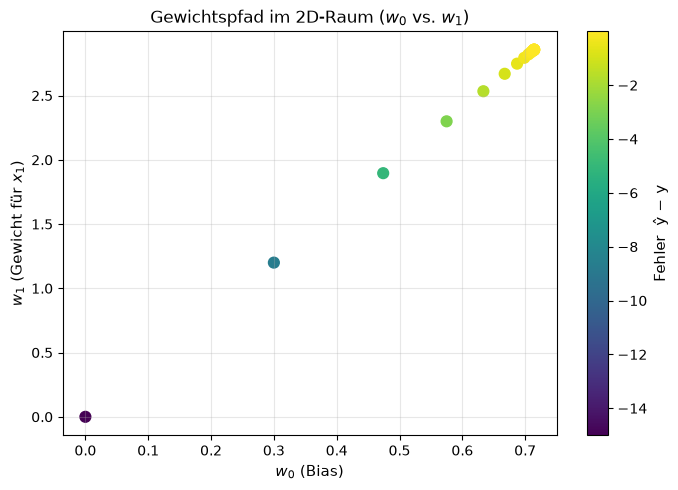

In [6]:
#| code-fold: true
#| code-summary: "Code anzeigen"

f_history = np.array([forward(cx, w) - cy for w in w_history])

plt.figure(figsize=(7, 5))
sc = plt.scatter(w_history[:, 0], w_history[:, 1], c=f_history, s=60)

cb = plt.colorbar(sc)
cb.set_label("Fehler  ŷ − y", fontsize=11)

plt.xlabel(r"$w_0$ (Bias)", fontsize=11)
plt.ylabel(r"$w_1$ (Gewicht für $x_1$)", fontsize=11)
plt.title(r"Gewichtspfad im 2D-Raum ($w_0$ vs. $w_1$)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

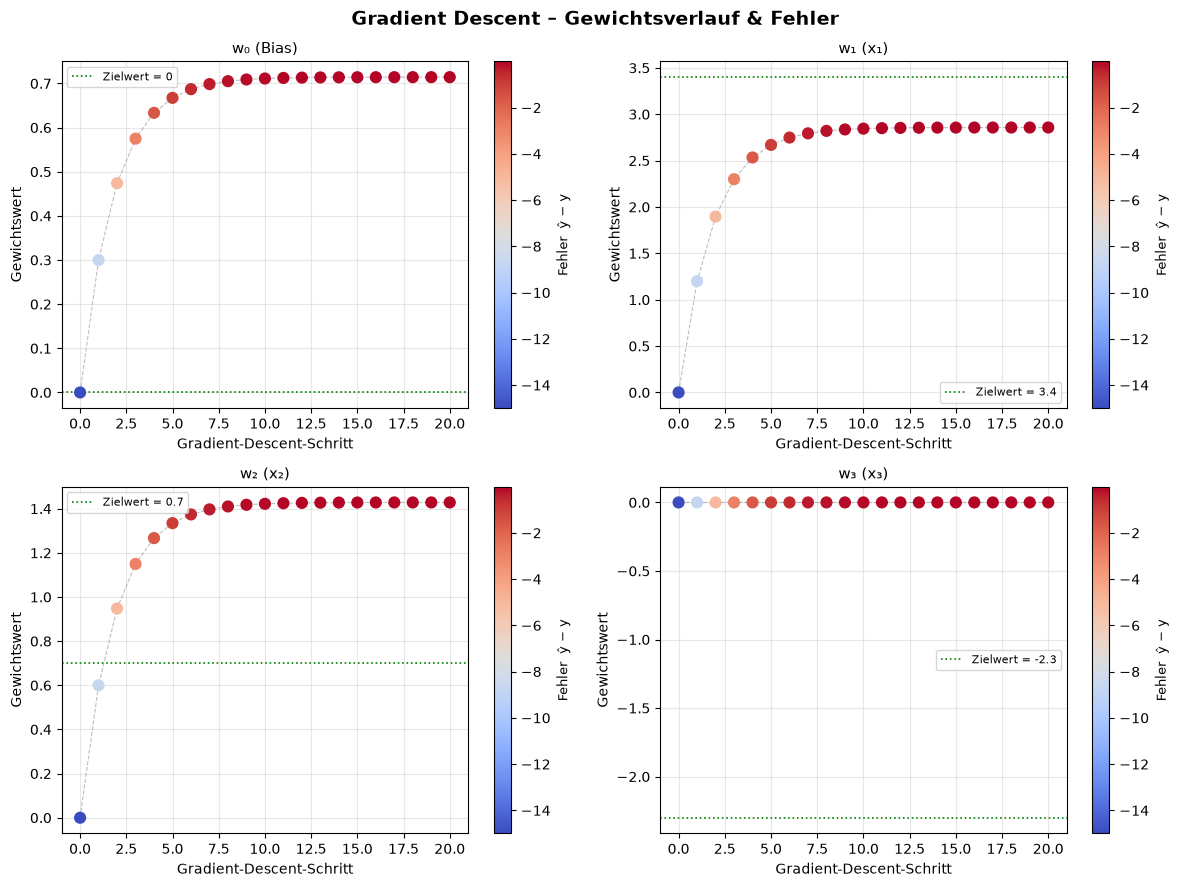

In [7]:
#|include: false
import numpy as np
import matplotlib.pyplot as plt

# ── Daten & Modell ──────────────────────────────────────────────────────────
Xtrain = [[1,2,3], [2,-3,4], [4,2,0]]
Ytrain = [3.4+1.4-6.9, 6.4-2.1-9.2, 13.6+1.4+0]

def forward(x, w):
    return np.dot(x, w)

ci = 2
cx = np.array([1] + Xtrain[ci])   # Bias-Term + Features → [1, 4, 2, 0]
cy = Ytrain[ci]                    # Zielwert
cw = np.zeros(4)
alpha = 0.01
w_history = [cw.copy()]

for _ in range(20):
    cg = 2 * cx * (np.dot(cx, cw) - cy)
    cw = cw - alpha * cg
    w_history.append(cw.copy())

w_history = np.array(w_history)
f_history = np.array([forward(cx, w) - cy for w in w_history])
steps     = np.arange(len(w_history))

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Gradient Descent – Gewichtsverlauf & Fehler", fontsize=14, fontweight="bold")

labels = ["w₀ (Bias)", "w₁ (x₁)", "w₂ (x₂)", "w₃ (x₃)"]
true_w = [0, 3.4, 0.7, -2.3]          # Referenzwerte aus der Formel

for i, ax in enumerate(axes.flat):
    sc = ax.scatter(steps, w_history[:, i],
                    c=f_history, cmap="coolwarm", s=60,
                    vmin=f_history.min(), vmax=f_history.max(), zorder=3)
    ax.plot(steps, w_history[:, i], color="gray", linewidth=0.8,
            linestyle="--", alpha=0.5, zorder=2)

    # Wahrer Wert als gestrichelte Referenzlinie
    ax.axhline(true_w[i], color="green", linewidth=1.2,
               linestyle=":", label=f"Zielwert = {true_w[i]}")

    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("Fehler  ŷ − y", fontsize=9)

    ax.set_title(labels[i], fontsize=11)
    ax.set_xlabel("Gradient-Descent-Schritt")
    ax.set_ylabel("Gewichtswert")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_weights.png", dpi=150, bbox_inches="tight")
plt.show()

Jetzt werden mehrere Datenpunkte verwendet. 

Das bisher trainierte Modell hat gelernt, genau einen Punkt vorherzusagen – für die anderen beiden Punkte wären die Gewichte nutzlos gewesen.

Nun wird das Modell mit mehrenen Datenpunkten, hier drei, trainiert. Damit wird das $\boldsymbol{\hat{x}}$ zu $\mathbf{\hat{X}}$, einer Matrix, die aus den Eingangsvekoren aller Datenpunkte besteht. $\hat{y}$ wird zum Vektor $\boldsymbol{\hat{y}}$, welcher die Zielwerte aller drei Datenpunkte enthält.

Der Gradient berechnet sich entsprechend als:

```
cg = (cx·w - y) · cx    →    entspricht:  Xᵀ(Xw - y)
```


Da das Modell jetzt auf allen drei Punkten trainiert, kann es zur wahren Lösung `w = [0, 3.4, 0.7, -2.3]` konvergieren. 

In [8]:
#| code-fold: true
#| code-summary: "Code anzeigen"

# Perfect Match
# y = x1*3.4 + x2*0.7 - x3*2.3
Xtrain = [[1,2,3], [2,-3,4], [4,2,0]]
Ytrain = [3.4+1.4-6.9, 6.4-2.1-9.2, 13.6+1.4+0]

def forward(x, w):
    return np.matmul(x,w)

cx = np.ones((3,4))
cx[:,1:] = np.array(Xtrain)
cy = np.array(Ytrain)

cw = np.zeros(4)

w_history = [cw]
alpha = 0.01
for i in range(200):
    cf = forward(cx, cw)
    print(cf, cf-cy, cw)

    # cg = 2*np.matmul(cx,(np.matmul(cx,cw) - cy))
    cg = np.matmul(np.matmul(cx,cw) - cy, cx)

    cw = cw - alpha*cg
    w_history.append(cw)
    
w_history = np.array(w_history)

[0. 0. 0.] [  2.1   4.9 -15. ] [0. 0. 0. 0.]
[ 0.594 -1.209  2.814] [  2.694   3.691 -12.186] [ 0.08   0.481  0.405 -0.259]
[ 0.95445 -2.19318  5.01987] [ 3.05445  2.70682 -9.98013] [ 0.13801  0.86768  0.70557 -0.48746]
[ 1.1508804 -2.9807226  6.7595922] [ 3.2508804  1.9192774 -8.2404078] [ 0.1801986  1.1822043  0.9252882 -0.6873663]
[ 1.23215008 -3.60187282  8.13992028] [ 3.33215008  1.29812718 -6.86007972] [ 0.2109011   1.44092626  1.08265707 -0.86166381]
[ 1.23290329 -4.08540209  9.2416997 ] [ 3.33290329  0.81459791 -5.7583003 ] [ 0.23319912  1.6560454   1.19215948 -1.0135534 ]
[ 1.17790101 -4.45699375 10.12654353] [ 3.27790101  0.44300625 -4.87345647] [ 0.24930712  1.83675643  1.26510536 -1.14612441]
[ 1.08495638 -4.73870302 10.84166811] [ 3.18495638  0.16129698 -4.15833189] [ 0.26083261  1.99005555  1.31030665 -1.26218169]
[ 0.96694607 -4.94898823 11.42343282] [ 3.06694607 -0.04898823 -3.57656718] [ 0.26895339  2.12131332  1.33461307 -1.36418226]
[ 0.83320414 -5.10301989 11.899956

# Warum neuronale Netze - das XOR-Problem

Bislang wurden Perceptronen verwendet und wichtige Grundlagen für neuronale Netze gelernt.
Die bislang gestellten Aufgabenstellungen konnten durch ein Perzeptron gelöst werden, bei komplexeren Problemen ist dies aber nicht mehr möglich, daher wird eine neue Lösung benötigt. 

Perceptronen können Daten klassifizieren, indem sie eine lineare Trennlinie finden, die die Daten aufteilt. 
Ein Beispiel, bei dem dies nicht mehr funktioniert, ist das XOR Problem. Das XOR-Problem kann aber mit einem neuronalen Netz gelöst werden.

## Aufgabe 2: XOR 

Stellen Sie die logische Funktion XOR durch AND, OR und NOT dar.

::: {.callout-note collapse="true"}
## Lösung anzeigen

A XOR B = (A AND (NOT B)) OR ((NOT A) AND B)    
:::

## Beispiel 1: Sicherheitsverriegelung mit zwei Positionssensoren

Eine industrielle Schutztür ist mit zwei unterschiedlichen Sensoren ausgestattet:

- **Sensor A:** Induktiver Näherungssensor  
  → erkennt eine Metallzunge  
- **Sensor B:** Magnetischer Reed-Kontakt  
  → erkennt einen Magneten  

Die Steuerung soll einen **Fehlerzustand melden**, wenn **genau einer der beiden Sensoren aktiv ist**.
Der Schwellwert zur Digitalisierung beträgt 2.5 V.

### Logik:

- Beide Sensoren 0 → Tür offen → kein Fehler  
- Beide Sensoren 1 → Tür korrekt geschlossen → kein Fehler  
- Genau ein Sensor 1 → Inkonsistenz → **Fehler (XOR)**  


| Messung | Sensor A (V) | Sensor B (V) | Digital A | Digital B | Fehler (XOR) |
|----------|--------------|--------------|------------|------------|--------------|
| 1 | 0.2 | 0.1 | 0 | 0 | 0 |
| 2 | 4.8 | 0.3 | 1 | 0 | 1 |
| 3 | 0.4 | 4.9 | 0 | 1 | 1 |
| 4 | 4.7 | 4.6 | 1 | 1 | 0 |

Die Daten für diesen XOR-Problem sehen also so aus:

In [9]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np

# Eingaben: 4 Punkte
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# Labels (XOR)
y = np.array([[0], [1], [1], [0]], dtype=float)

print ('X:', X)
print ('y:', y)


X: [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y: [[0.]
 [1.]
 [1.]
 [0.]]


Zur Lösung dieses Problems wird nun ein Netzwerk definiert:

Ein Perzeptron lernt OR, ein Perceptron lernt NOT AND. Die Kombination der beiden Perceptronen ergibt dann XOR.
Die beiden ersten Neuronen werden als _hidden layer_ bezeichnet, das dritte Neuron ist das Output Layer. Ein Netz, welches von links nach rechts durchgearbeitet wird, wird als Feed-Forward Netz bezeichnet. 

<figure style="text-align: center;">
    <img src="Bilder/XOR_Netz.svg" alt="Roboter" width = 500>
    <figcaption>Netzwerkarchitektur des Netzes, welches XOR lernen kann.</figcaption>
  </figure>

  
$\boldsymbol{x} = \begin{pmatrix} x_0  = 1\\ x_1 \\ x_2 \end{pmatrix}$ ist der Vektor, der die Eingangswerte enthält. 

$\mathbf{W}_{IH}$ ist die Matrix, die die Gewichte zwischen dem Input Layer und dem Hidden Layer beinhaltet
$$\mathbf{W}_{IH} = \begin{pmatrix} w_{IH,01} & w_{IH,11} & w_{IH,21} \\ w_{IH,02} & w_{IH,12} & w_{IH,22} \end{pmatrix}$$

Die Ausgänge der Perzeptrons im Hidden Layer sind $h_1$ und $h_2$.

Entsprechen ist $\mathbf{W}_{HO}$ ist die Matrix, die die Gewichte zwischen dem Hidden Layer und dem Output Layer beinhaltet
$$\mathbf{W}_{HO} = \begin{pmatrix} w_{HO,01} & w_{HO,11} & w_{HO,21} \end{pmatrix}$$


## Netzstruktur I - H - O

### gewichtete Summe von I nach H

$$\mathbf{W_{IH}} = \begin{pmatrix} w_{IH,01} & w_{IH,11} & w_{IH,21} \\ w_{IH,02} & w_{IH,12} & w_{IH,22} \end{pmatrix} $$

$$\boldsymbol{x} = \begin{pmatrix} x_{0} \\ x_{1} \\ x_{2} \end{pmatrix} $$

$$\mathbf{W_{IH}} \cdot \boldsymbol{x} = \begin{pmatrix}
w_{IH,01}x_0 + w_{IH,11}x_1 + w_{IH,21}x_2 \\
w_{IH,02}x_0 + w_{IH,12}x_1 + w_{IH,22}x_2
\end{pmatrix} $$

$\phi_H$ ist die Aktivierungsfunktion der Hidden Perzeptronen

$$\mathbf{H} = \begin{pmatrix} 1 \\
\phi_H\left(w_{IH,01}x_0 + w_{IH,11}x_1 + w_{IH,21}x_2 \right) \\
\phi_H\left(w_{IH,02}x_0 + w_{IH,12}x_1 + w_{IH,22}x_2 \right)
\end{pmatrix} $$

### gewichtete Summe von H nach O

$$\mathbf{W_{HO}} = \begin{pmatrix} w_{HO,01} & w_{HO,11} & w_{HO,21} \end{pmatrix} $$

$$\mathbf{W_{HO}} \cdot \mathbf{H}$$

$\phi_O$ ist die Aktivierungsfunktion des Outputperzeptrons

$$O = \phi_H \left( \mathbf{W_{HO}} \cdot \mathbf{H} \right)$$

### Struktur der Perzeptronen

Struktur der Input Layer Perzeptronen

Layer | Beschreibung | Aktivierungsfunktion
------|--------------|----------------------
I | $x_0 = 1$ (Bias $w_0$) | Aktivierungsfunktion ist identische Funktion $id(x)$ 
H | Struktur der Hidden Layer Perzeptronen $x_0 = 1$ (Bias $w_0$) | Aktivierungsfunktion ist sigmoid Funktion
O | Struktur der Output Layer Neuronen | $x_0 = 1$ (Bias $w_0$) |Aktivierungsfunktion ist sigmoid Funktion

## Zusammenfassung des neuronalen Netzes

### Input

$$
\boldsymbol{x} =
\begin{pmatrix}
1 \\
x_1 \\
x_2
\end{pmatrix}
$$

### Hidden

$$
\mathbf{H} =
\begin{pmatrix}
1 \\
\sigma(\mathbf{W_{IH}}\boldsymbol{x})_1 \\
\sigma(\mathbf{W_{IH}}\boldsymbol{x})_2
\end{pmatrix}
$$

### Output

$$
o = \sigma \left(\mathbf{W_{HO}}\mathbf{H} \right)
$$

### Gesamt

$$
o = \sigma\!\left(
\mathbf{W_{HO}}
\begin{pmatrix}
1 \\
\sigma(\mathbf{W_{IH}}\mathbf{x})
\end{pmatrix}
\right)
$$

## Vorwärtsberechnung des Netzes

In [10]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np
import matplotlib.pyplot as plt

def f_id(z):
    return z

def f_sigmoid(z):
    return 1/(1+np.exp(-z))


def add_bias_column(A):
    """Hängt eine 1-Spalte links an: (m,n) -> (m,n+1), Bias = x0 = 1."""
    return np.hstack([np.ones((A.shape[0], 1)), A])

# forward-pass
def predict(X,WIH,WHO):

    X1 = add_bias_column(X)     # Bias anhängen
    z1 = X1 @ WIH               # Gewichtete Summe, @ ist Kurzschreibweise für np.matmul oder np.dot
    a1 = f_sigmoid(z1)          # Aktivierungsfunktion
    h = add_bias_column(a1)     # Bias anhängen
    z2 = h @ WHO                # Gewichtete Summe
    a2 = f_sigmoid(z2)             # Outputfunktion

    cache = (X1, z1, a1, h, z2, a2)    # Werte zwischenspeichern

    return a2, cache

In [11]:
#| code-fold: true
#| code-summary: "Code anzeigen"
# forward-pass testen

WIH = np.array([
    [-10,  30],   # Bias w0
    [ 20, -20],   # x1
    [ 20, -20]    # x2
])

WHO = np.array([
    [-3],         # Bias
    [ 2],         # hidden 1
    [ 2]          # hidden 2
])

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y,_ = predict(X, WIH, WHO)
print(y)

[[0.26895927]
 [0.73102287]
 [0.73102287]
 [0.26895927]]


## Ableitung des Netzes

Die Ableitung des Netzes wird benötigt, um das Netz zu trainineren.
Dazu werden Traingsdaten $\left( \mathbf{\hat{X}}, \boldsymbol{\hat{y}} \right)$ verwendet.

### Kostenfunktion

$$E = \frac{1}{N} \sum_{i=1}^N\frac{1}{2} \left( \hat{y} - o \right)^2$$

### Outputfunktion

$$o = \sigma\!\left(
\mathbf{W_{HO}}
\begin{pmatrix}
1 \\
\sigma(\mathbf{W_{IH}}\mathbf{\hat{X}})
\end{pmatrix}
\right)$$

### Gradientenabstieg

Man benötigt Werte für die Änderung der Gewichte $W_{IH}$ und Werte für die Änderung der Gewichte $W_{HO}$.

Also

$$\nabla E = \left( \frac{\partial E}{\partial \mathbf{W}_{IH}} , \frac{\partial E}{\partial \mathbf{W}_{HO}} \right)$$

Diese müssen jeweils mit der Kettenregel berechnet werden.

In [12]:
#| include: false
# Anmerkung: Warum wird hier plötzlich sigma verwendet und nicht mehr phi?
# Weitere Korrekturen im Code: Später (bei der Funktion) wird für die Lernrate plötzlich lr statt alpha verwendet.

####  Änderung der Gewichte $W_{HO}$

\begin{aligned}
E &= \frac{1}{2} \left( \hat{y} - o \right)^2 \\
&= \frac{1}{2} \left( \hat{y} -  \sigma\left(\mathbf{W}_{HO} \cdot \sigma \left(\mathbf{W}_{IH}\cdot\mathbf{\hat{X}} \right) \right) \right)^2
\end{aligned}

Kettenregel

$$
\frac{\partial E}{\partial \mathbf{W}_{HO}}
=
\frac{\partial E}{\partial o}
\frac{\partial o}{\partial {z^O}}
\frac{\partial z^O}{\partial \mathbf{W}_{HO}}
$$

Die einzelnen Terme sind:

$$\frac{\partial E}{\partial o} = \frac{\partial}{\partial o} \frac{1}{2} \left(\hat{y}-o \right)^2 = - \frac{1}{2} 2 \left(\hat{y}-o \right) = o-y$$
$$\frac{\partial o}{\partial z^O} = \frac{\partial}{\partial z^O}  \sigma \left(z^O) \right) = \sigma^\prime \left(z^O) \right)$$
$$\frac{\partial z^O}{\partial \mathbf{W}_{HO}} 
= \frac{\partial}{\partial \mathbf{W}_{HO}} \begin{pmatrix} 1 \\ \boldsymbol{h}\end{pmatrix} = \begin{pmatrix} 1 \\ \boldsymbol{h}\end{pmatrix}^T$$

Damit ergibt sich:

$$ \frac{\partial E}{\partial \mathbf{W}_{HO}} = \left(o-\hat{y} \right)\sigma^\prime \left(z^O) \right) \begin{pmatrix} 1 \\ \boldsymbol{h}\end{pmatrix}^T 
= \delta^O \begin{pmatrix} 1 \\ \boldsymbol{h}\end{pmatrix}^T$$

####  Änderung der Gewichte $W_{IH}$

\begin{aligned}
E &= \frac{1}{2} \left( \hat{y} - o \right)^2 \\
&= \frac{1}{2} \left( \hat{y} -  \sigma\left(\mathbf{W}_{HO} \cdot \sigma \left(\mathbf{W}_{IH}\cdot\mathbf{\hat{X}} \right) \right) \right)^2
\end{aligned}

Kettenregel

$$
\frac{\partial E}{\partial \mathbf{W}_{IH}}
=
\frac{\partial E}{\partial o}
\frac{\partial o}{\partial {z^O}}
\frac{\partial z^O}{\partial \boldsymbol{h}}
\frac{\partial \boldsymbol{h}}{\partial \boldsymbol{z}^H}
\frac{\partial \boldsymbol{z}^H}{\partial \mathbf{W}_{IH}}
$$

Die einzelnen Terme sind:

$$\frac{\partial E}{\partial o} = \frac{\partial}{\partial o} \frac{1}{2} \left(\hat{y} - o \right)^2 = - \frac{1}{2} 2 \left(\hat{y} - o \right) = o - \hat{y}$$
$$\frac{\partial o}{\partial z^O} = \frac{\partial}{\partial z^O}  \sigma \left(z^O) \right) = \sigma^\prime \left(z^O) \right)$$
$$\frac{\partial z^O}{\partial \boldsymbol{h}} = \frac{\partial}{\partial \boldsymbol{h}} \mathbf{W}_{HO} \cdot \begin{pmatrix}1\\ \boldsymbol{h} \end{pmatrix} = \mathbf{W}_{HO}^{(\text{ohne Bias})}$$

\begin{align}
& \frac{\partial \boldsymbol{h}}{\partial \boldsymbol{z}^H} = \frac{\partial}{\partial \boldsymbol{z}^H} \sigma \left(\boldsymbol{z}^H\right) \\
&= \begin{pmatrix} \frac{\partial h_1}{\partial z^H_1} & \frac{\partial h_1}{\partial z^H_2} \\ \frac{\partial h_2}{\partial z^H_1} & \frac{\partial h_2}{\partial z^H_2} \end{pmatrix} \\
&= \begin{pmatrix} \frac{\partial \sigma\left(z^H_1\right)}{\partial z^H_1} & \frac{\partial \sigma\left(z^H_1\right)}{\partial z^H_2} \\ \frac{\partial \sigma\left(z^H_2\right)}{\partial z^H_1} & \frac{\partial \sigma\left(z^H_2\right)}{\partial z^H_2} \end{pmatrix} \\
&= \begin{pmatrix} \sigma^\prime \left(z^H_1\right) & 0 \\ 0 & \sigma^\prime\left(z^H_2\right) \end{pmatrix} \\
&= J_h \left(\boldsymbol{z}^H \right) \longrightarrow \odot \sigma'(z^H)
\end{align}

$$\frac{\partial \boldsymbol{z}^H}{\partial \mathbf{W}_{IH}} = \frac{\partial}{\partial \mathbf{W}_{IH}} \mathbf{W}_{IH}\cdot\mathbf{\hat{X}} 
= \mathbf{\hat{X}}^T$$


Damit ergibt sich

$$
\frac{\partial E}{\partial \mathbf{W}_{IH}}
=
(o-y)\,
\sigma'(z^O)\,
\mathbf{W}_{HO}^{(\text{ohne Bias})}
\odot
\sigma'(z^H)
\mathbf{\hat{X}}^T
=: \delta^H \mathbf{\hat{X}}^T
$$


In [13]:
#| include: false

#Informationen für den Vorlesenden:

#- Das Delta ist
#- Ableitungsschritte des Netzes einzeln erklären
#- Jakobi-Matrix erklären?

In [14]:
#| code-fold: true
#| code-summary: "Code anzeigen"

def f_dsigmoid(z):
    t = 1/(1+np.exp(-z))
    return t*(1-t)

def fit(X, y, WIH, WHO, n_iter, alpha=1.0):
    y = y.reshape(-1, 1)   # sicherstellen, dass y ein Spaltenvektor ist
    losses = []

    for i in range(n_iter):
        # 1) Forward Pass
        a2, cache = predict(X, WIH, WHO)
        X1, z1, a1, h, z2, a2 = cache

        # 2) Loss berechnen
        loss = 0.5 * np.mean((y - a2) ** 2)
        losses.append(loss)

        # 3) Output-Delta
        delta_O = (a2 - y) * f_dsigmoid(z2)

        # 4) Gradient für WHO
        grad_WHO = h.T @ delta_O

        # 5) Hidden-Delta
        WHO_no_bias = WHO[1:, :]          # Bias-Gewichte entfernen
        delta_H = (delta_O @ WHO_no_bias.T) * f_dsigmoid(z1)

        # 6) Gradient für WIH
        grad_WIH = X1.T @ delta_H

        # 7) Update
        N = X.shape[0]
        WIH = WIH - alpha * grad_WIH / N
        WHO = WHO - alpha * grad_WHO / N

        # 8) Ausgabe
        if i % 1000 == 0:
            print(i, loss)

    return WIH, WHO, losses
    
    

0 0.2224355363072268
1000 0.044763683991453335
2000 0.004321928051228933
3000 0.0019448139885901244
4000 0.0012230399854823415
5000 0.0008836856026125234
6000 0.0006885845517405039
7000 0.000562573025304443
8000 0.0004747573700401471
9000 0.0004101924230936522
[[0.01421753]
 [0.97243236]
 [0.97183572]
 [0.0336307 ]]
0.0003608390485071361


Text(0, 0.5, 'loss')

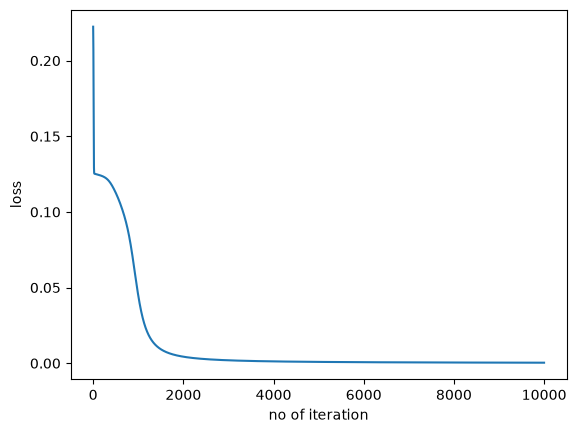

In [15]:
#| code-fold: true
#| code-summary: "Code anzeigen"

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 1, 1, 0], dtype=float).reshape(-1, 1)

np.random.seed(0)
WIH = np.random.randn(3,4) * 1.0
WHO = np.random.randn(5,1) * 1.0

WIH, WHO, losses = fit(X, y, WIH, WHO, n_iter=10000, alpha=1.0)

pred, _ = predict(X, WIH, WHO)
print(pred)
print(losses[-1])

plt.plot(losses)
plt.xlabel('no of iteration')
plt.ylabel('loss')

## Aufgabe 3: Lernen Visualisieren
Schreiben Sie eine Funktion plot, die das Lernen des Netzes visualisiert. 

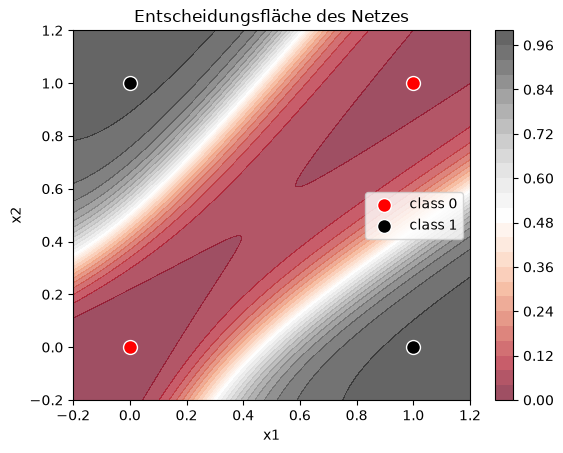

In [16]:
#| code-fold: true
#| code-summary: "Code anzeigen"

def plot(X, y, WIH, WHO):

    y = y.ravel()

    x_min, x_max = X[:,0].min()-0.2, X[:,0].max()+0.2
    y_min, y_max = X[:,1].min()-0.2, X[:,1].max()+0.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    zz, _ = predict(grid, WIH, WHO)
    zz = zz.reshape(xx.shape)

    cont = plt.contourf(xx, yy, zz, levels=30, alpha=0.7, cmap="RdGy")

    colors = {1: "black", 0: "red"}

    for cls in np.unique(y):
        mask = (y == cls)
        plt.scatter(X[mask,0],X[mask,1],color=colors[int(cls)],edgecolor="white",s=100,label=f"class {int(cls)}"
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Entscheidungsfläche des Netzes")
    plt.legend()
    plt.colorbar(cont)

plot(X, y, WIH, WHO)

## Aufgabe 4: Aktivierungsfunktion verändern
Nutzen Sie statt sigmoid ReLu als Aktivierungsfunktion des hidden Layers.

In [17]:
#| code-fold: true
#| code-summary: "Code anzeigen"

import numpy as np

def f_id(z):
    return z

def f_sigmoid(z):
    return 1/(1+np.exp(-z))

def f_ReLU(z):
    return np.maximum(0,z)

def f_dsigmoid(z):
    t = 1/(1+np.exp(-z))
    return t*(1-t)

def f_dReLU(z):
    return (z > 0).astype(float)

def add_bias_column(A):
    """Hängt eine 1-Spalte links an: (m,n) -> (m,n+1), Bias = x0 = 1."""
    return np.hstack([np.ones((A.shape[0], 1)), A])

# forward-pass
def predict(X,WIH,WHO):

    X1 = add_bias_column(X)     # Bias anhängen
    z1 = X1 @ WIH               # Gewichtete Summe, @ ist Kurzschreibweise für np.matmul oder np.dot
    a1 = f_ReLU(z1)             # Aktivierungsfunktion
    h = add_bias_column(a1)     # Bias anhängen
    z2 = h @ WHO                # Gewichtete Summe
    a2 = f_sigmoid(z2)          # Outputfunktion

    cache = (X1, z1, a1, h, z2, a2)    # Werte zwischenspeichern

    return a2, cache

def fit(X, y, WIH, WHO, n_iter, alpha=1.0):
    y = y.reshape(-1, 1)   # sicherstellen, dass y ein Spaltenvektor ist
    losses = []

    for i in range(n_iter):
        # 1) Forward Pass
        a2, cache = predict(X, WIH, WHO)
        X1, z1, a1, h, z2, a2 = cache

        # 2) Loss berechnen
        loss = 0.5 * np.mean((y - a2) ** 2)
        losses.append(loss)

        # 3) Output-Delta
        delta_O = (a2 - y) * f_dsigmoid(z2)

        # 4) Gradient für WHO
        grad_WHO = h.T @ delta_O

        # 5) Hidden-Delta
        WHO_no_bias = WHO[1:, :]          # Bias-Gewichte entfernen
        delta_H = (delta_O @ WHO_no_bias.T) * f_dReLU(z1)

        # 6) Gradient für WIH
        grad_WIH = X1.T @ delta_H

        # 7) Update
        N = X.shape[0]
        WIH = WIH - alpha * grad_WIH / N
        WHO = WHO - alpha * grad_WHO / N

        # 8) Ausgabe
        if i % 1000 == 0:
            print(i, loss)

    return WIH, WHO, losses
    
    

In [18]:
#| code-fold: true
#| code-summary: "Code anzeigen"

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 1, 1, 0], dtype=float).reshape(-1, 1)

np.random.seed(0)
WIH = np.random.randn(3,4) * 1.0
WHO = np.random.randn(5,1) * 1.0

WIH, WHO, losses = fit(X, y, WIH, WHO, n_iter=10000, alpha=1.0)

pred, _ = predict(X, WIH, WHO)
print(pred)
print(losses[-1])

0 0.2478382373032334
1000 0.0005279797700787904
2000 0.0001948366694676992
3000 0.0001142696196290561
4000 7.946020646063369e-05
5000 6.028898075153374e-05
6000 4.8286208739788995e-05
7000 4.010495550658793e-05
8000 3.419954917699128e-05
9000 2.974093358959339e-05
[[0.00764134]
 [0.99415858]
 [0.99179842]
 [0.00709702]]
2.627227832039998e-05


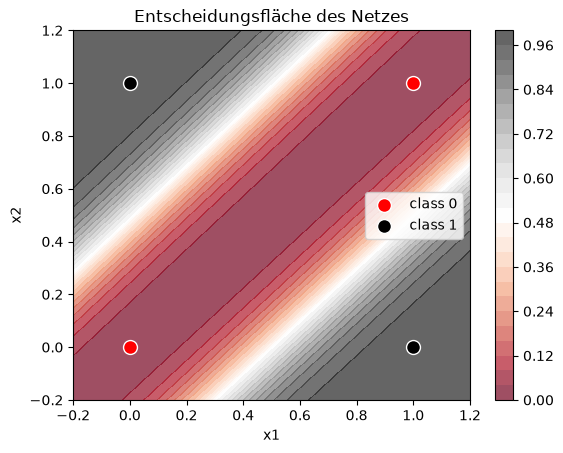

In [19]:
#| code-fold: true
#| code-summary: "Code anzeigen"

def plot(X, y, WIH, WHO):

    y = y.ravel()

    x_min, x_max = X[:,0].min()-0.2, X[:,0].max()+0.2
    y_min, y_max = X[:,1].min()-0.2, X[:,1].max()+0.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    zz, _ = predict(grid, WIH, WHO)
    zz = zz.reshape(xx.shape)

    cont = plt.contourf(xx, yy, zz, levels=30, alpha=0.7, cmap="RdGy")

    colors = {1: "black", 0: "red"}

    for cls in np.unique(y):
        mask = (y == cls)
        plt.scatter(X[mask,0],X[mask,1],color=colors[int(cls)],edgecolor="white",s=100,label=f"class {int(cls)}"
    )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Entscheidungsfläche des Netzes")
    plt.legend()
    plt.colorbar(cont)

plot(X, y, WIH, WHO)

## Aufgabe 5: Backpropagation für einfaches Netz 
Berechnen Sie die die Gewichtsänderungen für folgendes einfaches neuronales Netz

<figure  style="text-align: center;">
    <img src="Bilder/einfaches_Netz.svg" alt="einfaches Netz" width = 300>
    <figcaption>Ein sehr einfaches Netz</figcaption>
</figure>


# Einfaches neuronales Netzwerk "Zu Fuß"

Im Folgenden wird ein einfaches Netzwerk, welches den Datensatz eines Polymoms 'lernt', implementiert.
Die zu lernende Funktion sei

$$
f(x) = \frac{1}{2}x^3 - 2x^2 + x
$$

Im Wertebereich $x \in [-2.5; 2.5]$.

In [20]:
# notwendige Pakete importieren

import numpy as np
import matplotlib.pyplot as plt

Definition der / des 'wahren' Funktion / Modells.

In [21]:
def true_fun(x):
    return 0.5*x**3 - 2.0*x**2 + 1.0*x

In [22]:
#| include: false

#def true_fun(x):
#    return 25*x**3 - 100.0*x**2 + 50.0*x

Ziel ist es, diese Funktion anhand von Messdaten zu simulieren. Dabei wird angenommen, dass die oben definierte Funktion dem zugrunde liegenden „wahren“ Modell entspricht. In realen Messprozessen treten jedoch statistische Messfehler auf, sodass die beobachteten Daten von den tatsächlichen Funktionswerten abweichen.

Um diesen Effekt nachzubilden, wird den Funktionswerten ein simuliertes Rauschen im Wertebereich hinzugefügt. Auf diese Weise entstehen realitätsnahe Datenpunkte, die die Unsicherheiten und Streuungen echter Messungen widerspiegeln.

In [23]:
rng = np.random.default_rng(0)
N = 300
X = rng.uniform(-2.5, 2.5, size=(N, 1))
Y = true_fun(X) + rng.normal(0, 0.8, size=(N, 1))

In [24]:
#| include: false

#rng = np.random.default_rng(0)
#N = 300
#X = rng.uniform(-2.5, 2.5, size=(N, 1))
#Y = true_fun(X) + rng.normal(0, 20.0, size=(N, 1))

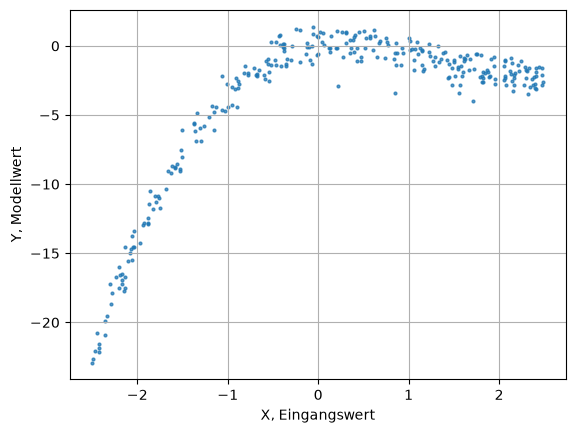

In [25]:
# grafische Darstellung der Funktion

plt.scatter(X, Y, s=4, alpha=0.75)
plt.xlabel("X, Eingangswert")
plt.ylabel("Y, Modellwert")
plt.grid()

Wie bereits zuvor, werden die Daten in 80% Trainingsdaten und 20% Testdaten aufgeteilt.

In [26]:
# Train/Test-Split
perm = rng.permutation(N)
split = int(0.8 * N)
Xtr, Ytr = X[perm[:split]], Y[perm[:split]]
Xte, Yte = X[perm[split:]], Y[perm[split:]]

## Training

Im Folgenden werden die Daten mit einem einfachen Netz traniert.

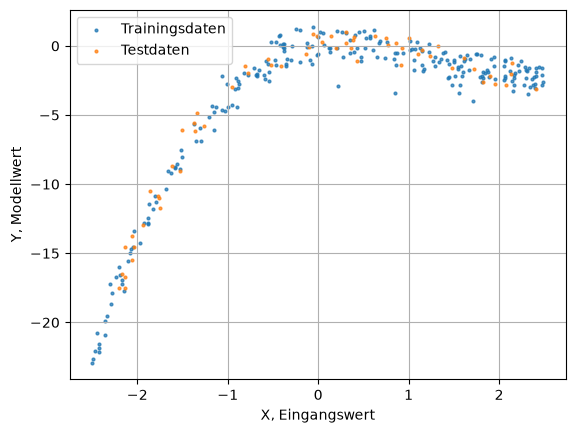

In [27]:
plt.scatter(Xtr, Ytr, s=4, alpha=0.75, label="Trainingsdaten")
plt.scatter(Xte, Yte, s=4, alpha=0.75, label="Testdaten")
plt.xlabel("X, Eingangswert")
plt.ylabel("Y, Modellwert")
plt.legend()
plt.grid()

Für das Neuronale Netz werden wieder Hilfsfunktionen definiert, die die Aktivierungsfunktion und deren Ableitung darstellen. 
In diesem Fall soll es $\tanh$ sein. Als Kostenfunktion wird wieder der mittlere quadratische Fehler verwendet. Darum werden hier auch dieser und seine Ableitung als Hilfsfunktion definiert. 

In [28]:
def tanh(z): 
    return np.tanh(z)

def dtanh(z):
    t = np.tanh(z)
    return 1.0 - t*t

def mse(yhat, y):
    return 0.5 * ((yhat - y) ** 2).mean()

def mse_grad(yhat, y):
    return (yhat - y) / y.shape[0]

Im nächsten Schritt wird das neuronale Netzwerk definiert. Hierzu wird eine eigene Klasse implementiert, die die Struktur und Funktionsweise des Netzes beschreibt.

Die Klasse NN dient zur Definition eines neuronalen Netzwerks, bestehend aus einem Eingangslayer, zwei versteckten Layern sowie einem Ausgabelayer.

In [29]:
#| include: false

# Glorot, kann man das evtl rausnehmen?
# Normalisierung im ersten Teil lieber komplett rausnehmen
# Glorot genauer erklären, wozu nimmt man das? Tritt auch nur bei der Initializierung der Ws und bs auf. 
# (Glorot-Initialisierung)[https://towardsdatascience.com/xavier-glorot-initialization-in-neural-networks-math-proof-4682bf5c6ec3/]
# (Understanding the difficulty of training deep feedforward neural networks)[https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf]

In [30]:
class NN:
    def __init__(self, in_dim=1, h1=20, h2=20, seed=1):
        rng = np.random.default_rng(seed)
        # Glorot-Normal (gut für tanh)
        def glorot(fan_in, fan_out):
            std = np.sqrt(2.0 / (fan_in + fan_out))
            return rng.normal(0.0, std, size=(fan_in, fan_out))

        self.W1 = glorot(in_dim, h1); self.b1 = np.zeros((1, h1))
        self.W2 = glorot(h1, h2);     self.b2 = np.zeros((1, h2))
        self.W3 = glorot(h2, 1);      self.b3 = np.zeros((1, 1))

    # Netzwerk forwärts durchlaufen
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = tanh(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = tanh(z2)
        yhat = a2 @ self.W3 + self.b3
        cache = (X, z1, a1, z2, a2, yhat)
        return yhat, cache

    # Netzwerk rückwärts durchlaufen (fürs Training)
    def backward(self, cache, yhat, y, l2=0.0):
        X, z1, a1, z2, a2, _ = cache

        dy = mse_grad(yhat, y)

        # Layer 3
        dW3 = a2.T @ dy
        db3 = dy.sum(axis=0, keepdims=True)

        # Layer 2
        da2 = dy @ self.W3.T
        dz2 = da2 * dtanh(z2)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        # Layer 1
        da1 = dz2 @ self.W2.T
        dz1 = da1 * dtanh(z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        # L2 (optional) auf Gewichte
        if l2 > 0.0:
            dW3 += l2 * self.W3
            dW2 += l2 * self.W2
            dW1 += l2 * self.W1

        grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}
        return grads

    # Update der Gewichte anhand eines Gradienten und einer Lernrate
    def step(self, grads, lr):
        self.W1 -= lr * grads["W1"]; self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]; self.b2 -= lr * grads["b2"]
        self.W3 -= lr * grads["W3"]; self.b3 -= lr * grads["b3"]

In [31]:
model = NN(in_dim=1, h1=20, h2=20, seed=1)
epochs = 800
lr = 0.03
batch = 64
l2 = 0.0  # z.B. 1e-4 für leichte Glättung

train_hist = []
test_hist = []

for ep in range(1, epochs + 1):
    idx = rng.permutation(len(Xtr))
    for i in range(0, len(idx), batch):
        b = idx[i:i+batch]
        xb, yb = Xtr[b], Ytr[b]

        yhat, cache = model.forward(xb)
        grads = model.backward(cache, yhat, yb, l2=l2)
        model.step(grads, lr)

    # Tracking (auf skalierten Größen)
    yhat_tr, _ = model.forward(Xtr)
    yhat_te, _ = model.forward(Xte)
    train_hist.append(mse(yhat_tr, Ytr))
    test_hist.append(mse(yhat_te, Yte))

    if ep % 100 == 0 or ep == 1:
        print(f"Epoch {ep:3d} | MSE train {train_hist[-1]:.4f} | MSE test {test_hist[-1]:.4f}")


Epoch   1 | MSE train 16.8916 | MSE test 16.9912
Epoch 100 | MSE train 0.9459 | MSE test 1.4135
Epoch 200 | MSE train 0.3652 | MSE test 0.2989
Epoch 300 | MSE train 0.4361 | MSE test 0.5639
Epoch 400 | MSE train 0.3231 | MSE test 0.3496
Epoch 500 | MSE train 0.4096 | MSE test 0.5077
Epoch 600 | MSE train 0.4632 | MSE test 0.5449
Epoch 700 | MSE train 0.4910 | MSE test 0.6275
Epoch 800 | MSE train 0.3901 | MSE test 0.4523


## Test

In [32]:
# Denormierte Vorhersagen auf Test
yhat_te_dn = yhat_te
mse_test_dn = mse(yhat_te_dn, Yte)
ss_res = float(((yhat_te_dn - Yte) ** 2).sum())
ss_tot = float(((Yte - Yte.mean()) ** 2).sum())
r2 = 1.0 - ss_res / ss_tot
print(f"Denormierte Test-MSE: {mse_test_dn:.4f} | R^2: {r2:.3f}")

Denormierte Test-MSE: 0.4523 | R^2: 0.972


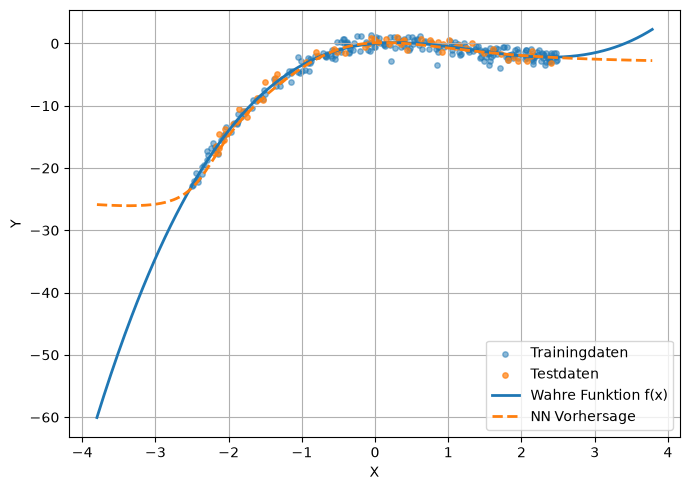

In [33]:
# Fit-Kurve gegen wahres Modell und Datenpunkte
xgrid = np.linspace(X.min()-1.3, X.max()+1.3, 400, dtype=np.float32).reshape(-1, 1)
ygrid, _ = model.forward(xgrid)

plt.figure(figsize=(7, 5))
plt.scatter(Xtr, Ytr, s=15, alpha=0.5, label="Trainingdaten")
plt.scatter(Xte, Yte, s=15, alpha=0.7, label="Testdaten")
plt.plot(xgrid, true_fun(xgrid), linewidth=2, label="Wahre Funktion f(x)")
plt.plot(xgrid, ygrid, linewidth=2, linestyle="--", label="NN Vorhersage")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.tight_layout()

# Normalisierung

## Aufgabe 6: Funktion verändern

Ändern sie die Funktion in folgende Funktion

$$
f(x) = 25x^3 - 100x^2 + 50x
$$

Im Wertebereich $x \in [-2.5; 2.5]$. Ändern Sie die Streuung des Rauschens von $0.8$ auf $20.0$.

Was passiert beim Training des Models und der Vorhersage der Werte?


In [34]:
#| include: false

def true_fun(x):
    return 25*x**3 - 100.0*x**2 + 50.0*x

rng = np.random.default_rng(0)
N = 300
X = rng.uniform(-2.5, 2.5, size=(N, 1))
Y = true_fun(X) + rng.normal(0, 20.0, size=(N, 1))


Epoch   1 | MSE train 16.8421 | MSE test 16.9295
Epoch 100 | MSE train 0.4572 | MSE test 0.5990
Epoch 200 | MSE train 0.3517 | MSE test 0.2983
Epoch 300 | MSE train 0.3289 | MSE test 0.3515
Epoch 400 | MSE train 0.3321 | MSE test 0.3745
Epoch 500 | MSE train 0.3382 | MSE test 0.3928
Epoch 600 | MSE train 0.3297 | MSE test 0.3307
Epoch 700 | MSE train 0.3501 | MSE test 0.3470
Epoch 800 | MSE train 0.3319 | MSE test 0.3674
Denormierte Test-MSE: 73981.4453 | R^2: -0.542


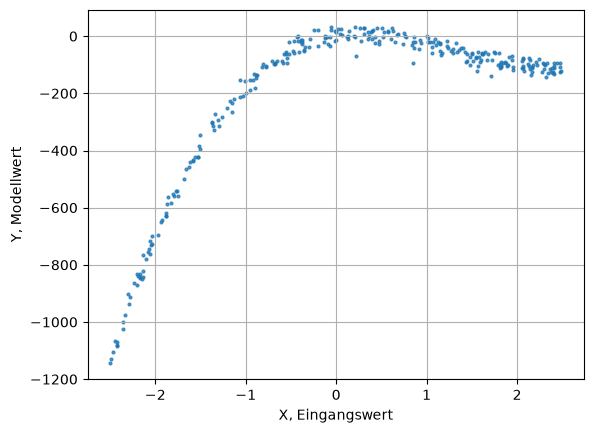

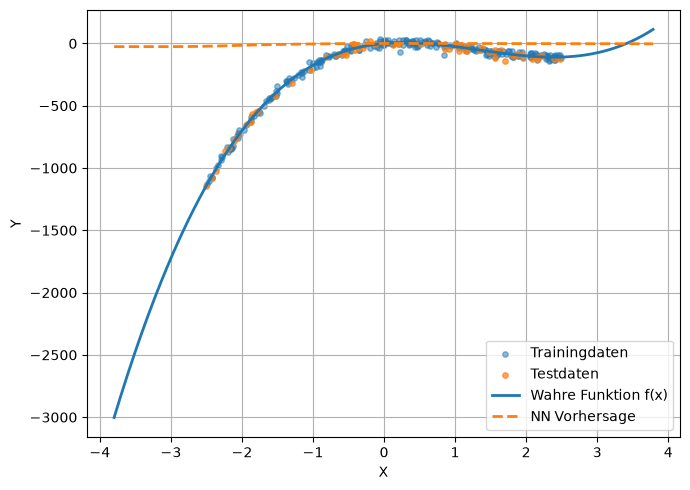

In [35]:
#| include: false

# grafische Darstellung der Funktion

plt.scatter(X, Y, s=4, alpha=0.75)
plt.xlabel("X, Eingangswert")
plt.ylabel("Y, Modellwert")
plt.grid()

model = NN(in_dim=1, h1=20, h2=20, seed=1)
epochs = 800
lr = 0.03
batch = 64
l2 = 0.0  # z.B. 1e-4 für leichte Glättung

train_hist = []
test_hist = []

for ep in range(1, epochs + 1):
    idx = rng.permutation(len(Xtr))
    for i in range(0, len(idx), batch):
        b = idx[i:i+batch]
        xb, yb = Xtr[b], Ytr[b]

        yhat, cache = model.forward(xb)
        grads = model.backward(cache, yhat, yb, l2=l2)
        model.step(grads, lr)

    # Tracking (auf skalierten Größen)
    yhat_tr, _ = model.forward(Xtr)
    yhat_te, _ = model.forward(Xte)
    train_hist.append(mse(yhat_tr, Ytr))
    test_hist.append(mse(yhat_te, Yte))

    if ep % 100 == 0 or ep == 1:
        print(f"Epoch {ep:3d} | MSE train {train_hist[-1]:.4f} | MSE test {test_hist[-1]:.4f}")

# Train/Test-Split
perm = rng.permutation(N)
split = int(0.8 * N)
Xtr, Ytr = X[perm[:split]], Y[perm[:split]]
Xte, Yte = X[perm[split:]], Y[perm[split:]]

# Denormierte Vorhersagen auf Test
yhat_te_dn = yhat_te
mse_test_dn = mse(yhat_te_dn, Yte)
ss_res = float(((yhat_te_dn - Yte) ** 2).sum())
ss_tot = float(((Yte - Yte.mean()) ** 2).sum())
r2 = 1.0 - ss_res / ss_tot
print(f"Denormierte Test-MSE: {mse_test_dn:.4f} | R^2: {r2:.3f}")

# Fit-Kurve gegen wahres Modell und Datenpunkte
xgrid = np.linspace(X.min()-1.3, X.max()+1.3, 400, dtype=np.float32).reshape(-1, 1)
ygrid, _ = model.forward(xgrid)

plt.figure(figsize=(7, 5))
plt.scatter(Xtr, Ytr, s=15, alpha=0.5, label="Trainingdaten")
plt.scatter(Xte, Yte, s=15, alpha=0.7, label="Testdaten")
plt.plot(xgrid, true_fun(xgrid), linewidth=2, label="Wahre Funktion f(x)")
plt.plot(xgrid, ygrid, linewidth=2, linestyle="--", label="NN Vorhersage")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.tight_layout()


## Training mit Normalisierung

Beim Training sowie bei der Modellvorhersage fällt auf, dass die Qualität der Vorhersage im Vergleich zur zuvor betrachteten Funktion deutlich schlechter ist.

Der Grund hierfür liegt darin, dass sich die x- und y-Werte nun stark in ihrer Größenordnung unterscheiden. Diese unterschiedliche Skalierung wirkt sich negativ auf den Optimierungsprozess aus: Der Optimierer behandelt beide Variablen formal gleich, obwohl sie aufgrund ihrer Größenordnung einen unterschiedlich starken Einfluss auf den Fehlerterm (z. B. den Mean Squared Error, MSE) haben.

Eine bewährte Lösung für dieses Problem ist die Normalisierung (bzw. Skalierung) der Daten vor dem Training. Dabei werden die Werte auf eine vergleichbare Größenordnung gebracht, sodass der Optimierer effizienter arbeiten kann.

Nach der Modellvorhersage müssen die zuvor skalierten Werte anschließend wieder in die ursprüngliche Skala zurücktransformiert werden, um interpretierbare Ergebnisse zu erhalten.

Dies wird im Folgenden mit der sogenannten  [Standardisierung](https://de.wikipedia.org/wiki/Standardisierung_(Statistik)) anhand dieses Beispiels dargestellt.

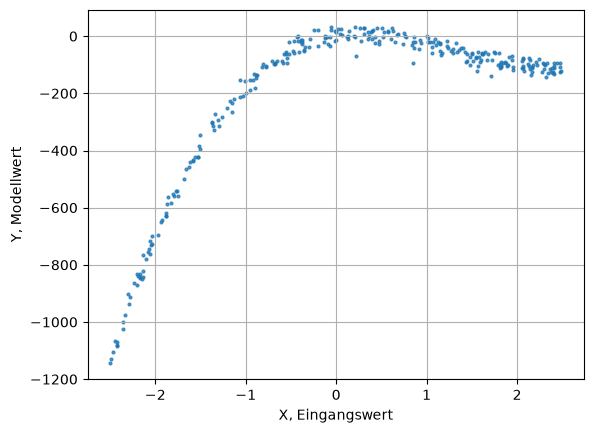

In [36]:
def true_fun(x):
    return 25*x**3 - 100.0*x**2 + 50.0*x

rng = np.random.default_rng(0)
N = 300
X = rng.uniform(-2.5, 2.5, size=(N, 1))
Y = true_fun(X) + rng.normal(0, 20.0, size=(N, 1))

# grafische Darstellung der Funktion

plt.scatter(X, Y, s=4, alpha=0.75)
plt.xlabel("X, Eingangswert")
plt.ylabel("Y, Modellwert")
plt.grid()

In [37]:
# Train/Test-Split
perm = rng.permutation(N)
split = int(0.8 * N)
Xtr, Ytr = X[perm[:split]], Y[perm[:split]]
Xte, Yte = X[perm[split:]], Y[perm[split:]]

# Standardisierung (stabilisiert Training deutlich)
x_mean = Xtr.mean(axis=0, keepdims=True)
x_std  = Xtr.std(axis=0, keepdims=True) + 1e-8 # die + 1e-8 verhindert eine Division durch Null
y_mean = Ytr.mean(axis=0, keepdims=True)
y_std  = Ytr.std(axis=0, keepdims=True) + 1e-8

Xs_tr = (Xtr - x_mean) / x_std
Xs_te = (Xte - x_mean) / x_std
Ys_tr = (Ytr - y_mean) / y_std
Ys_te = (Yte - y_mean) / y_std

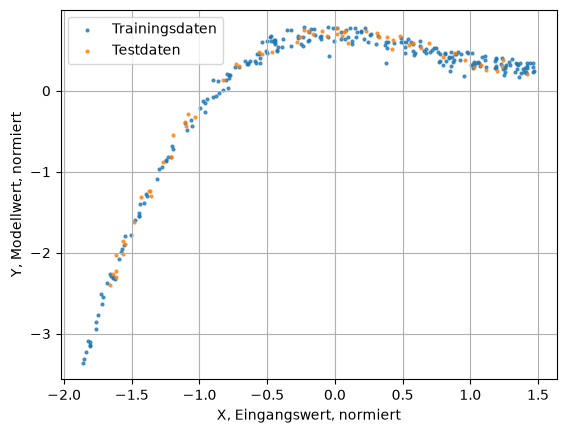

In [38]:
plt.scatter(Xs_tr, Ys_tr, s=4, alpha=0.75, label="Trainingsdaten")
plt.scatter(Xs_te, Ys_te, s=4, alpha=0.75, label="Testdaten")
plt.xlabel("X, Eingangswert, normiert")
plt.ylabel("Y, Modellwert, normiert")
plt.legend()
plt.grid()

In [39]:
# Hier werden wieder die auch schon zuvor verwendeten Hilfsfunktionen definiert

def tanh(z): 
    return np.tanh(z)

def dtanh(z):
    t = np.tanh(z)
    return 1.0 - t*t

def mse(yhat, y):
    return 0.5 * ((yhat - y) ** 2).mean()

def mse_grad(yhat, y):
    return (yhat - y) / y.shape[0]

In [40]:
# Erneut das neuronale Netz von zuvor nutzen

class NN:
    def __init__(self, in_dim=1, h1=20, h2=20, seed=1):
        rng = np.random.default_rng(seed)
        # Glorot-Normal (gut für tanh)
        def glorot(fan_in, fan_out):
            std = np.sqrt(2.0 / (fan_in + fan_out))
            return rng.normal(0.0, std, size=(fan_in, fan_out))

        self.W1 = glorot(in_dim, h1); self.b1 = np.zeros((1, h1))
        self.W2 = glorot(h1, h2);     self.b2 = np.zeros((1, h2))
        self.W3 = glorot(h2, 1);      self.b3 = np.zeros((1, 1))

    # Netzwerk forwärts durchlaufen
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = tanh(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = tanh(z2)
        yhat = a2 @ self.W3 + self.b3
        cache = (X, z1, a1, z2, a2, yhat)
        return yhat, cache

    # Netzwerk rückwärts durchlaufen (fürs Training)
    def backward(self, cache, yhat, y, l2=0.0):
        X, z1, a1, z2, a2, _ = cache

        dy = mse_grad(yhat, y)

        # Layer 3
        dW3 = a2.T @ dy
        db3 = dy.sum(axis=0, keepdims=True)

        # Layer 2
        da2 = dy @ self.W3.T
        dz2 = da2 * dtanh(z2)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        # Layer 1
        da1 = dz2 @ self.W2.T
        dz1 = da1 * dtanh(z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        # L2 (optional) auf Gewichte
        if l2 > 0.0:
            dW3 += l2 * self.W3
            dW2 += l2 * self.W2
            dW1 += l2 * self.W1

        grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}
        return grads

    # Update der Gewichte anhand eines Gradienten und einer Lernrate
    def step(self, grads, lr):
        self.W1 -= lr * grads["W1"]; self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]; self.b2 -= lr * grads["b2"]
        self.W3 -= lr * grads["W3"]; self.b3 -= lr * grads["b3"]

In [41]:
# Training des Netzes

model = NN(in_dim=1, h1=20, h2=20, seed=1)
epochs = 800
lr = 0.03
batch = 64
l2 = 0.0  # z.B. 1e-4 für leichte Glättung

train_hist = []
test_hist = []

for ep in range(1, epochs + 1):
    idx = rng.permutation(len(Xs_tr))
    for i in range(0, len(idx), batch):
        b = idx[i:i+batch]
        xb, yb = Xs_tr[b], Ys_tr[b]

        yhat, cache = model.forward(xb)
        grads = model.backward(cache, yhat, yb, l2=l2)
        model.step(grads, lr)

    # Tracking (auf skalierten Größen)
    yhat_tr, _ = model.forward(Xs_tr)
    yhat_te, _ = model.forward(Xs_te)
    train_hist.append(mse(yhat_tr, Ys_tr))
    test_hist.append(mse(yhat_te, Ys_te))

    if ep % 100 == 0 or ep == 1:
        print(f"Epoch {ep:3d} | MSE train {train_hist[-1]:.4f} | MSE test {test_hist[-1]:.4f}")


Epoch   1 | MSE train 0.3818 | MSE test 0.3695
Epoch 100 | MSE train 0.1391 | MSE test 0.0981
Epoch 200 | MSE train 0.0186 | MSE test 0.0117
Epoch 300 | MSE train 0.0083 | MSE test 0.0073
Epoch 400 | MSE train 0.0062 | MSE test 0.0059
Epoch 500 | MSE train 0.0050 | MSE test 0.0050
Epoch 600 | MSE train 0.0043 | MSE test 0.0043
Epoch 700 | MSE train 0.0039 | MSE test 0.0039
Epoch 800 | MSE train 0.0035 | MSE test 0.0034


In [ ]:
# Denormierte Vorhersagen auf Test. 

yhat_te_dn = yhat_te * y_std + y_mean #
mse_test_dn = mse(yhat_te_dn, Yte)
ss_res = float(((yhat_te_dn - Yte) ** 2).sum())
ss_tot = float(((Yte - Yte.mean()) ** 2).sum())
r2 = 1.0 - ss_res / ss_tot
print(f"Denormierte Test-MSE: {mse_test_dn:.4f} | R^2: {r2:.3f}")

Denormierte Test-MSE: 269.7455 | R^2: 0.993


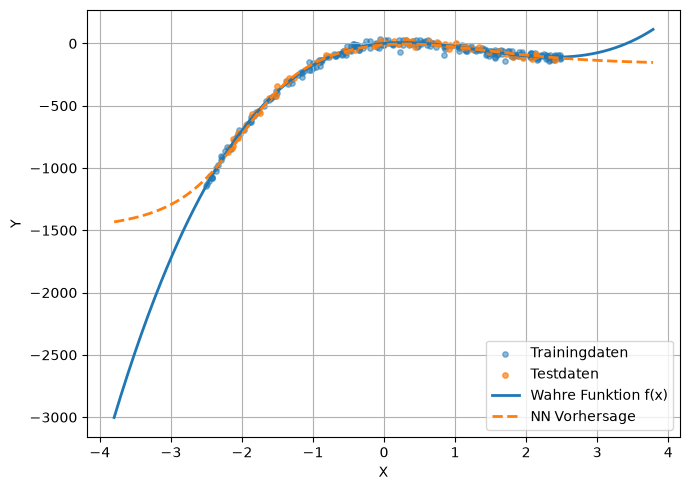

In [ ]:
# Fit-Kurve gegen wahres Modell und Datenpunkte
xgrid = np.linspace(X.min()-1.3, X.max()+1.3, 400, dtype=np.float32).reshape(-1, 1) # Wertebereich für Funktion und Vorhersage definieren
xgrid_s = (xgrid - x_mean) / x_std # Skalieren für Eingabe ins trainierte Model
ygrid_s, _ = model.forward(xgrid_s) # Forwärtspfad, um y zu berechnen
ygrid = ygrid_s * y_std + y_mean # y Rücktransformieren

plt.figure(figsize=(7, 5))
plt.scatter(Xtr, Ytr, s=15, alpha=0.5, label="Trainingdaten")
plt.scatter(Xte, Yte, s=15, alpha=0.7, label="Testdaten")
plt.plot(xgrid, true_fun(xgrid), linewidth=2, label="Wahre Funktion f(x)")
plt.plot(xgrid, ygrid, linewidth=2, linestyle="--", label="NN Vorhersage")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.tight_layout()

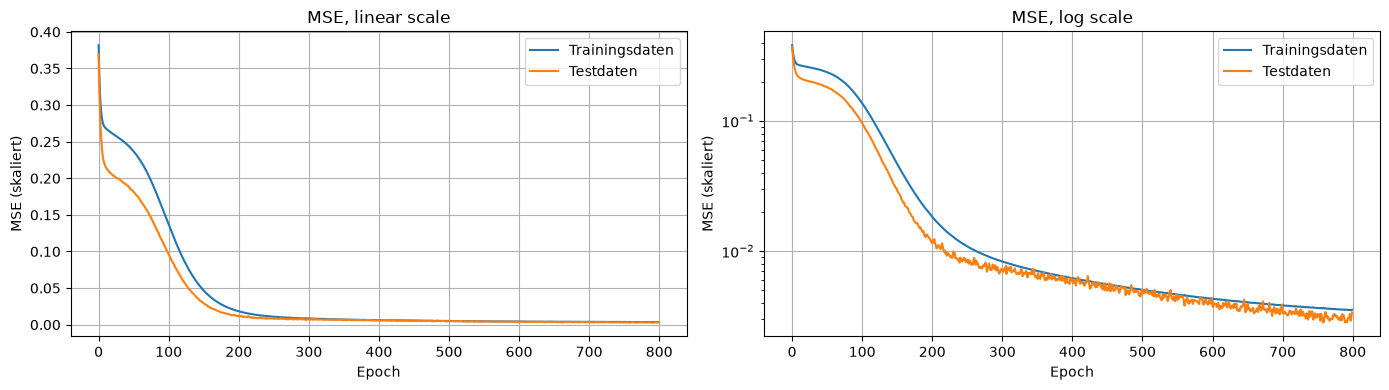

In [44]:
# Lernkurven (MSE auf skalierten Targets)

fig, [ax1, ax2] = plt.subplots(1,2, figsize=(14, 4))
ax1.plot(train_hist, label="Trainingsdaten")
ax1.plot(test_hist, label="Testdaten")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE (skaliert)")
ax1.set_title("MSE, linear scale")
ax1.legend()
ax1.grid()

ax2.plot(train_hist, label="Trainingsdaten")
ax2.plot(test_hist, label="Testdaten")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE (skaliert)")
ax2.set_title("MSE, log scale")
ax2.legend()
ax2.grid()
ax2.set_yscale('log')

fig.tight_layout()


## Möglichkeiten der Normalisierung

Die Normalisierung von Daten ist ein wichtiger Schritt beim Training neuronaler Netze. Sie sorgt dafür, dass Eingangs- und Zielwerte in einer vergleichbaren Größenordnung liegen, was den Optimierungsprozess stabiler und effizienter macht. Ohne Normalisierung können große Werte den Fehler (z. B. den MSE) dominieren und das Training erschweren oder verlangsamen.

Es gibt verschiedene einfache Verfahren zur Normalisierung, die auch in Keras verfügbar sind. Drei typische Beispiele sind:

Standardisierung (Z-Score): Transformation auf Mittelwert 0 und Standardabweichung 1
→ keras.layers.Normalization()

Min-Max-Skalierung: Werte werden auf einen festen Bereich (z. B. [0, 1]) skaliert
→ z. B. mit sklearn.preprocessing.MinMaxScaler vor dem Training

Rescaling: einfache lineare Skalierung, z. B. Division durch einen festen Wert
→ keras.layers.Rescaling(scale=1./255)

Wichtig ist, dass die Parameter der Normalisierung (z. B. Mittelwert und Standardabweichung) ausschließlich auf den Trainingsdaten berechnet werden. Diese Transformation wird anschließend auch auf die Testdaten angewendet. Dadurch kann es vorkommen, dass Testdaten nach der Normalisierung Werte außerhalb des ursprünglich erwarteten Bereichs annehmen – dies ist korrekt und vermeidet sogenannte Data Leakage.

## Beispiel mit MinMaxScaler

In [45]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Beispieldaten erzeugen
rng = np.random.default_rng(0)
X = rng.uniform(-2.5, 2.5, size=(300, 1))
Y = 25*X**3 - 100*X**2 + 50*X + rng.normal(0, 20, size=(300, 1))

# Aufteilen in Trainings- und Testdaten
Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.2, random_state=0)

# Scaler definieren
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# NUR auf Trainingsdaten fitten
Xtr_scaled = x_scaler.fit_transform(Xtr)
Ytr_scaled = y_scaler.fit_transform(Ytr)

# Testdaten nur transformieren
Xte_scaled = x_scaler.transform(Xte)
Yte_scaled = y_scaler.transform(Yte)

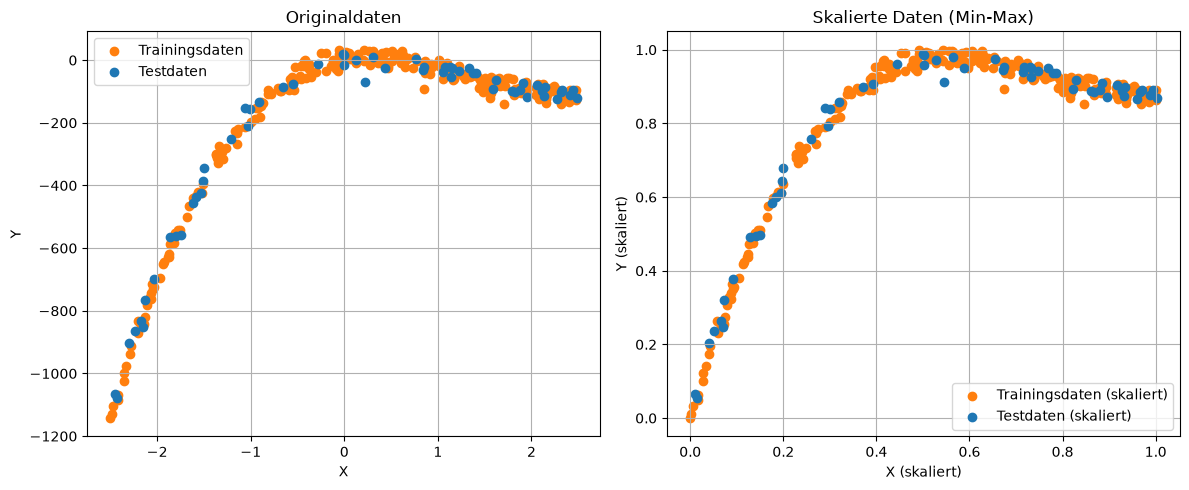

In [46]:
#grafische Darstellung der Original und skalierten Daten

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Originaldaten
axes[0].scatter(Xtr, Ytr, color='C1', label='Trainingsdaten')
axes[0].scatter(Xte, Yte, color='C0', label='Testdaten')
axes[0].set_title("Originaldaten")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].legend()
axes[0].grid()

# Skalierte Daten
axes[1].scatter(Xtr_scaled, Ytr_scaled, color='C1', label='Trainingsdaten (skaliert)')
axes[1].scatter(Xte_scaled, Yte_scaled, color='C0', label='Testdaten (skaliert)')
axes[1].set_title("Skalierte Daten (Min-Max)")
axes[1].set_xlabel("X (skaliert)")
axes[1].set_ylabel("Y (skaliert)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [47]:
# Rücktransformation

Y_pred_scaled = Yte_scaled  # beziehungsweise model.predict(Xte_scaled)
Y_pred = y_scaler.inverse_transform(Y_pred_scaled)

## Aufgabe 7: MinMaxScaler

Trainieren Sie erneut das Netz aus dem Kapitel [Training mit Normalisierung](#training-mit-normalisierung) und nutzen Sie zur Normalisierung den MinMaxScaler.

Epoch   1 | MSE train 4426.6486 | MSE test 4428.9039
Epoch 100 | MSE train 0.0290 | MSE test 0.0291
Epoch 200 | MSE train 0.0292 | MSE test 0.0289
Epoch 300 | MSE train 0.0291 | MSE test 0.0295
Epoch 400 | MSE train 0.0290 | MSE test 0.0292
Epoch 500 | MSE train 0.0290 | MSE test 0.0293
Epoch 600 | MSE train 0.0290 | MSE test 0.0291
Epoch 700 | MSE train 0.0291 | MSE test 0.0289
Epoch 800 | MSE train 0.0293 | MSE test 0.0289


ValueError: operands could not be broadcast together with shapes (60,1) (240,1) 

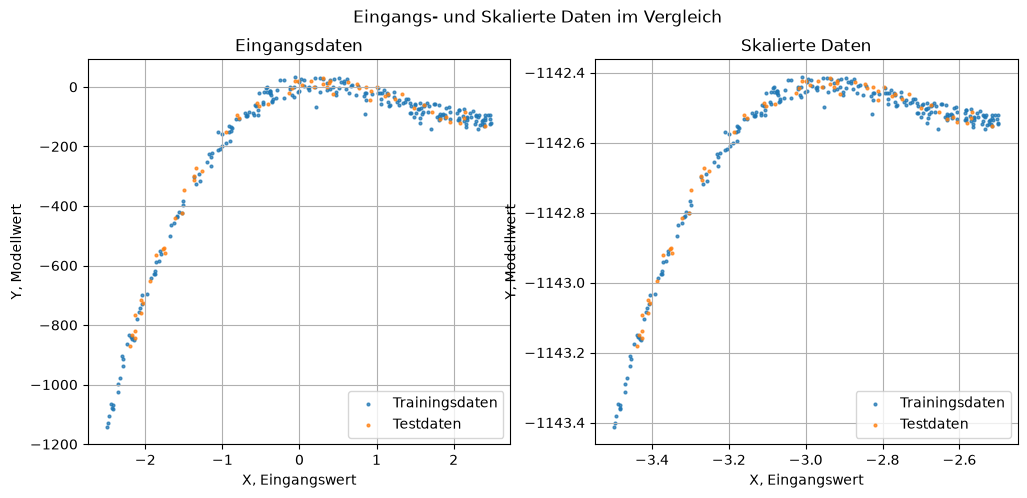

In [ ]:
# |include: false

### Hier die Lösung mit MinMaxScaler ohne Scikidlearn

### Daten erzeugen

def true_fun(x):
    return 25*x**3 - 100.0*x**2 + 50.0*x

rng = np.random.default_rng(0)
N = 300
X = rng.uniform(-2.5, 2.5, size=(N, 1))
Y = true_fun(X) + rng.normal(0, 20.0, size=(N, 1))

# Train/Test-Split
perm = rng.permutation(N)
split = int(0.8 * N)
Xtr, Ytr = X[perm[:split]], Y[perm[:split]]
Xte, Yte = X[perm[split:]], Y[perm[split:]]

# Standardisierung (mit MinMax Scaler)

xmax = Xtr.max(axis=0)
xmin = Xtr.min(axis=0)

ymax = Ytr.max(axis=0)
ymin = Ytr.min(axis=0)

x_std = (Xtr - xmax) / (xmax-xmin) + xmin
y_std = (Ytr - ymax) / (ymax-ymin) + ymin

Xs_tr = (Xtr - xmax) / (xmax-xmin) + xmin
Xs_te = (Xte - xmax) / (xmax-xmin) + xmin
Ys_tr = (Ytr - ymax) / (ymax-ymin) + ymin
Ys_te = (Yte - ymax) / (ymax-ymin) + ymin



# grafische Darstellung der Funktion und der normalisierten Funktion

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.suptitle('Eingangs- und Skalierte Daten im Vergleich')

axes[0].scatter(Xtr, Ytr, s=4, alpha=0.75, label = 'Trainingsdaten')
axes[0].scatter(Xte, Yte, s=4, alpha=0.75, label = 'Testdaten')
axes[0].set_xlabel("X, Eingangswert")
axes[0].set_ylabel("Y, Modellwert")
axes[0].grid()
axes[0].set_title('Eingangsdaten')
axes[0].legend()

axes[1].scatter(Xs_tr, Ys_tr, s=4, alpha=0.75, label = 'Trainingsdaten')
axes[1].scatter(Xs_te, Ys_te, s=4, alpha=0.75, label = 'Testdaten')
axes[1].set_xlabel("X, Eingangswert")
axes[1].set_ylabel("Y, Modellwert")
axes[1].grid()
axes[1].set_title('Skalierte Daten')
axes[1].legend()


### Hilfsfunktionen definieren

def tanh(z): 
    return np.tanh(z)

def dtanh(z):
    t = np.tanh(z)
    return 1.0 - t*t

def mse(yhat, y):
    return 0.5 * ((yhat - y) ** 2).mean()

def mse_grad(yhat, y):
    return (yhat - y) / y.shape[0]

# Erneut das neuronale Netz von zuvor nutzen

class NN:
    def __init__(self, in_dim=1, h1=20, h2=20, seed=1):
        rng = np.random.default_rng(seed)
        # Glorot-Normal (gut für tanh)
        def glorot(fan_in, fan_out):
            std = np.sqrt(2.0 / (fan_in + fan_out))
            return rng.normal(0.0, std, size=(fan_in, fan_out))

        self.W1 = glorot(in_dim, h1); self.b1 = np.zeros((1, h1))
        self.W2 = glorot(h1, h2);     self.b2 = np.zeros((1, h2))
        self.W3 = glorot(h2, 1);      self.b3 = np.zeros((1, 1))

    # Netzwerk forwärts durchlaufen
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = tanh(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = tanh(z2)
        yhat = a2 @ self.W3 + self.b3
        cache = (X, z1, a1, z2, a2, yhat)
        return yhat, cache

    # Netzwerk rückwärts durchlaufen (fürs Training)
    def backward(self, cache, yhat, y, l2=0.0):
        X, z1, a1, z2, a2, _ = cache

        dy = mse_grad(yhat, y)

        # Layer 3
        dW3 = a2.T @ dy
        db3 = dy.sum(axis=0, keepdims=True)

        # Layer 2
        da2 = dy @ self.W3.T
        dz2 = da2 * dtanh(z2)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        # Layer 1
        da1 = dz2 @ self.W2.T
        dz1 = da1 * dtanh(z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        # L2 (optional) auf Gewichte
        if l2 > 0.0:
            dW3 += l2 * self.W3
            dW2 += l2 * self.W2
            dW1 += l2 * self.W1

        grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}
        return grads

    # Update der Gewichte anhand eines Gradienten und einer Lernrate
    def step(self, grads, lr):
        self.W1 -= lr * grads["W1"]; self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]; self.b2 -= lr * grads["b2"]
        self.W3 -= lr * grads["W3"]; self.b3 -= lr * grads["b3"]

# Training des Netzes

model = NN(in_dim=1, h1=20, h2=20, seed=1)
epochs = 800
lr = 0.03
batch = 64
l2 = 0.0  # z.B. 1e-4 für leichte Glättung

train_hist = []
test_hist = []

for ep in range(1, epochs + 1):
    idx = rng.permutation(len(Xs_tr))
    for i in range(0, len(idx), batch):
        b = idx[i:i+batch]
        xb, yb = Xs_tr[b], Ys_tr[b]

        yhat, cache = model.forward(xb)
        grads = model.backward(cache, yhat, yb, l2=l2)
        model.step(grads, lr)

    # Tracking (auf skalierten Größen)
    yhat_tr, _ = model.forward(Xs_tr)
    yhat_te, _ = model.forward(Xs_te)
    train_hist.append(mse(yhat_tr, Ys_tr))
    test_hist.append(mse(yhat_te, Ys_te))

    if ep % 100 == 0 or ep == 1:
        print(f"Epoch {ep:3d} | MSE train {train_hist[-1]:.4f} | MSE test {test_hist[-1]:.4f}")


# Denormierte Vorhersagen auf Test / Rücktransformation
yhat_te_dn = yhat_te * y_std + y_mean
mse_test_dn = mse(yhat_te_dn, Yte)
ss_res = float(((yhat_te_dn - Yte) ** 2).sum())
ss_tot = float(((Yte - Yte.mean()) ** 2).sum())
r2 = 1.0 - ss_res / ss_tot
print(f"Denormierte Test-MSE: {mse_test_dn:.4f} | R^2: {r2:.3f}")

# Fit-Kurve gegen wahres Modell und Datenpunkte
xgrid = np.linspace(X.min()-1.3, X.max()+1.3, 400, dtype=np.float32).reshape(-1, 1)
xgrid_s = (xgrid - x_mean) / x_std
ygrid_s, _ = model.forward(xgrid_s)
ygrid = ygrid_s * y_std + y_mean

plt.figure(figsize=(7, 5))
plt.scatter(Xtr, Ytr, s=15, alpha=0.5, label="Trainingdaten")
plt.scatter(Xte, Yte, s=15, alpha=0.7, label="Testdaten")
plt.plot(xgrid, true_fun(xgrid), linewidth=2, label="Wahre Funktion f(x)")
plt.plot(xgrid, ygrid, linewidth=2, linestyle="--", label="NN Vorhersage")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.tight_layout()
plt.title('Ergebnis nach Training des NN')


# Overfitting

Overfitting bei neuronalen Netzen bedeutet, dass das Modell die Trainingsdaten zu genau lernt, einschließlich zufälliger Störungen (Rauschen). Dadurch passt es sich sehr gut an die Trainingsdaten an, generalisiert aber schlecht auf neue, unbekannte Daten. Das Modell erkennt dann nicht mehr die zugrunde liegenden Muster, sondern „merkt sich“ einzelne Datenpunkte. Typische Anzeichen sind ein sehr kleiner Trainingsfehler bei gleichzeitig hohem Fehler auf Testdaten. Ursachen können ein zu komplexes Modell, zu viele Parameter oder zu wenig Trainingsdaten sein.


Um das Problem des Overfitting an einem einfachen Beispiel zu verdeutlichen, wird ein Polynom verschiedener Ordnungen an Messwerte angepasst.

## Aufgabe 8: Polynom fitten

In der Datei [messwerte.txt](Daten/UeberwachtesLernen/messwerte.txt) finden Sie 15 Messwerte entsprechend einer leicht verrauschten Normalverteilung. Nutzen Sie `numpy.polyfit`, um Polynome an die Messwerte zu fitten. Erstellen Sie Fits von Grad 1 bis zur Interpolation bei Grad 14 und plotten Sie diese. 

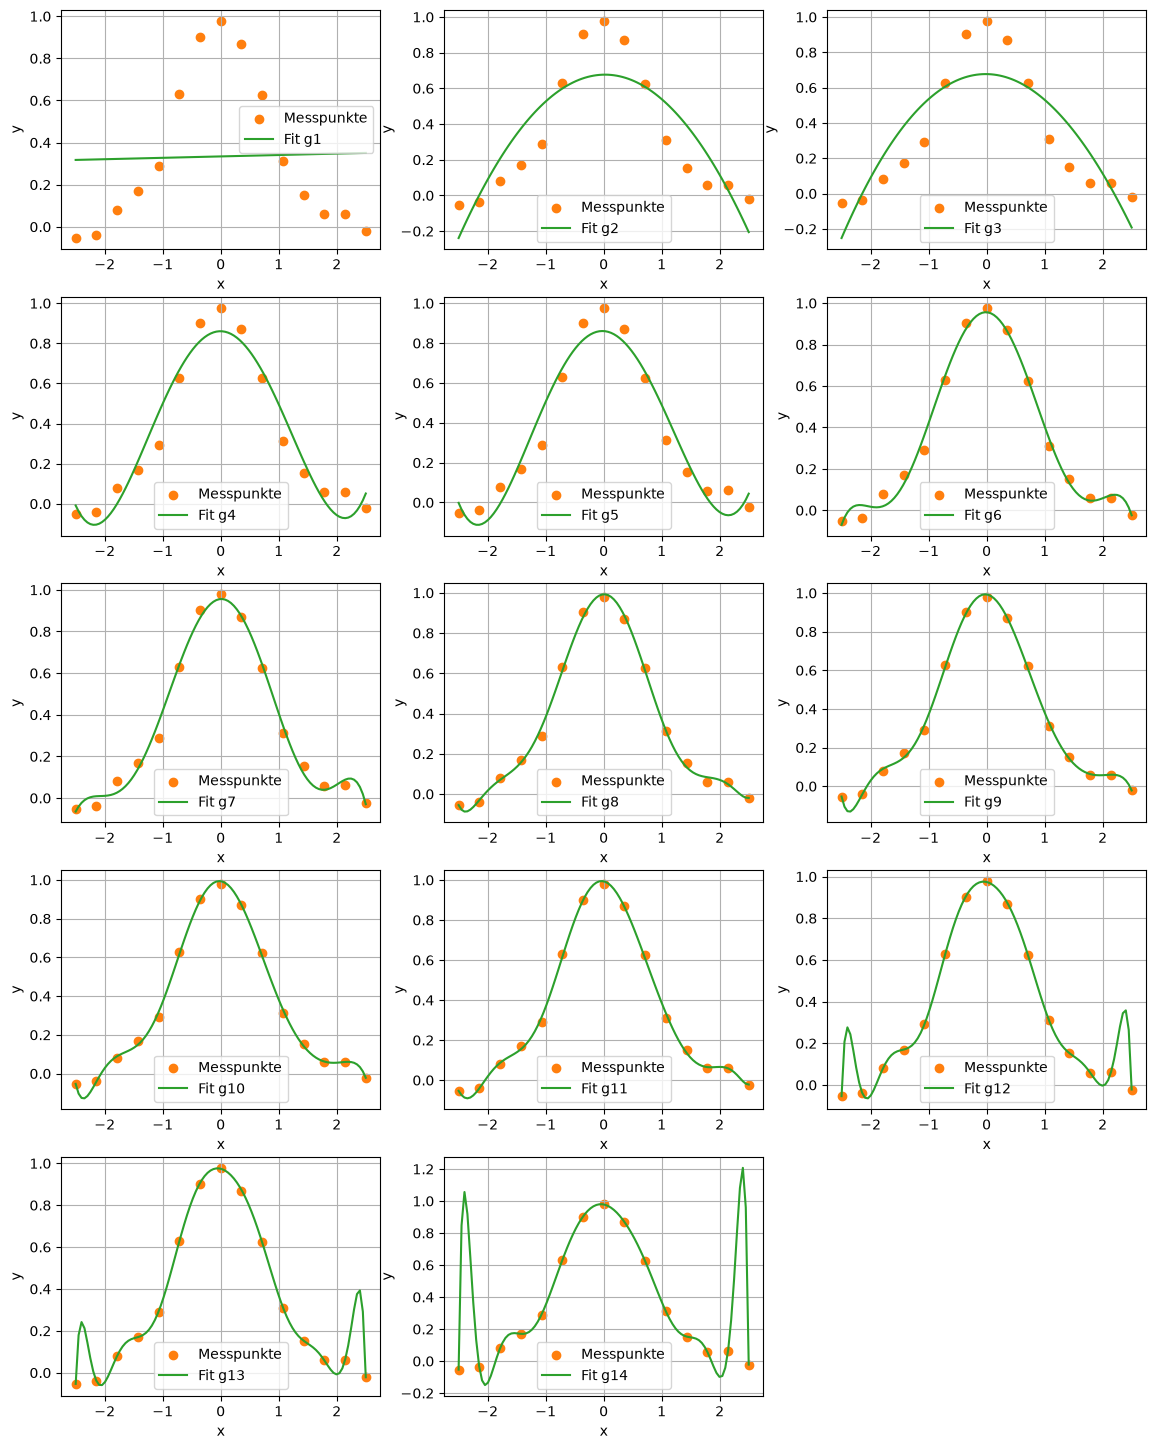

In [49]:
import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt('Daten/UeberwachtesLernen/messwerte.txt')
data_x = data[:, 0]
data_y = data[:, 1]

plt.figure(figsize=[14, 18])

for i in range(1, 15):

    P = np.polyfit(data_x, data_y, i)

    fit_x = np.linspace(-2.5, 2.5, 100)

    plt.subplot(5,3,i)
    plt.scatter(data_x, data_y, color='C1', label="Messpunkte")
    plt.plot(fit_x, np.polyval(P, fit_x), color='C2', label=f'Fit g{i}')

    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid();

In diesem Beispiel werden Polynome unterschiedlicher Ordnung an dieselben Messdaten angepasst. Für kleine Grade (z. B. g1–g3) ist das Modell zu einfach und kann die Struktur der Daten nicht gut erfassen (Underfitting). Mit zunehmendem Grad (z. B. g5–g8) beschreibt das Modell die Daten immer besser und findet eine sinnvolle Annäherung an den zugrunde liegenden Zusammenhang. Ab sehr hohen Graden (z. B. g12–g14) beginnt das Modell jedoch, auch das Rauschen der Messdaten zu „lernen“, was sich in starken Schwingungen insbesondere an den Rändern zeigt – das ist Overfitting.

Overfitting bedeutet also, dass ein Modell zwar die Trainingsdaten sehr gut beschreibt, aber die eigentliche zugrunde liegende Funktion nicht mehr generalisiert. Übertragen auf neuronale Netze passiert genau das Gleiche: Ein zu komplexes Netz mit vielen Parametern kann Trainingsdaten nahezu perfekt auswendig lernen, verliert aber die Fähigkeit, neue Daten korrekt vorherzusagen.


## Overfitting beim Neuronalen Netz

Im vorigen Abschnitt wurde Overfitting anhand von Polynomen unterschiedlicher Ordnung gezeigt. Das gleiche Phänomen tritt auch bei neuronalen Netzen auf: Ein zu komplexes Netz mit zu vielen Epochen lernt die Trainingsdaten auswendig – und verliert dabei die Fähigkeit, neue Daten korrekt vorherzusagen.

In dieser Aufgabe 9 wird  Overfitting zunächst absichtlich provoziert, um dann mit verschiedenen Gegenmaßnahmen bekämpfen.

### Aufgabe 9 (a): Overfitting provozieren

Trainieren Sie das bekannte Netz (`NN` mit `h1=20, h2=20`) auf einem **sehr kleinen Trainingsdatensatz** (nur 15 zufällig gewählte Punkte aus dem Datensatz [messwerte2.txt](Daten/UeberwachtesLernen/messwerte2.txt)) für viele Epochen (z.B. 2000).

Plotten Sie anschließend den Training- und Test-Loss über die Epochen.

**Fragen:**
- Ab welcher Epoche beginnt der Test-Loss zu steigen, während der Training-Loss weiter sinkt?
- Was bedeutet das für die Qualität des Modells auf unbekannten Daten?

In [50]:
#| code-fold: true
#| code-summary: "Bekanntes NN und Aktivierungsfunktionen anzeigen"
# Die NN-Klasse wird hier erneut definiert, damit die Aufgaben unabhängig ausführbar sind

class NN:
    def __init__(self, in_dim=1, h1=20, h2=20, seed=1):
        rng = np.random.default_rng(seed)
        # Glorot-Normal (gut für tanh)
        def glorot(fan_in, fan_out):
            std = np.sqrt(2.0 / (fan_in + fan_out))
            return rng.normal(0.0, std, size=(fan_in, fan_out))

        self.W1 = glorot(in_dim, h1); self.b1 = np.zeros((1, h1))
        self.W2 = glorot(h1, h2);     self.b2 = np.zeros((1, h2))
        self.W3 = glorot(h2, 1);      self.b3 = np.zeros((1, 1))

    # Netzwerk forwärts durchlaufen
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = tanh(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = tanh(z2)
        yhat = a2 @ self.W3 + self.b3
        cache = (X, z1, a1, z2, a2, yhat)
        return yhat, cache

    # Netzwerk rückwärts durchlaufen (fürs Training)
    def backward(self, cache, yhat, y, l2=0.0):
        X, z1, a1, z2, a2, _ = cache

        dy = mse_grad(yhat, y)

        # Layer 3
        dW3 = a2.T @ dy
        db3 = dy.sum(axis=0, keepdims=True)

        # Layer 2
        da2 = dy @ self.W3.T
        dz2 = da2 * dtanh(z2)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        # Layer 1
        da1 = dz2 @ self.W2.T
        dz1 = da1 * dtanh(z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}
        return grads

    # Update der Gewichte anhand eines Gradienten und einer Lernrate
    def step(self, grads, lr):
        self.W1 -= lr * grads["W1"]; self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]; self.b2 -= lr * grads["b2"]
        self.W3 -= lr * grads["W3"]; self.b3 -= lr * grads["b3"]


def tanh(z): 
    return np.tanh(z)

def dtanh(z):
    t = np.tanh(z)
    return 1.0 - t*t

def mse(yhat, y):
    return 0.5 * ((yhat - y) ** 2).mean()

def mse_grad(yhat, y):
    return (yhat - y) / y.shape[0]


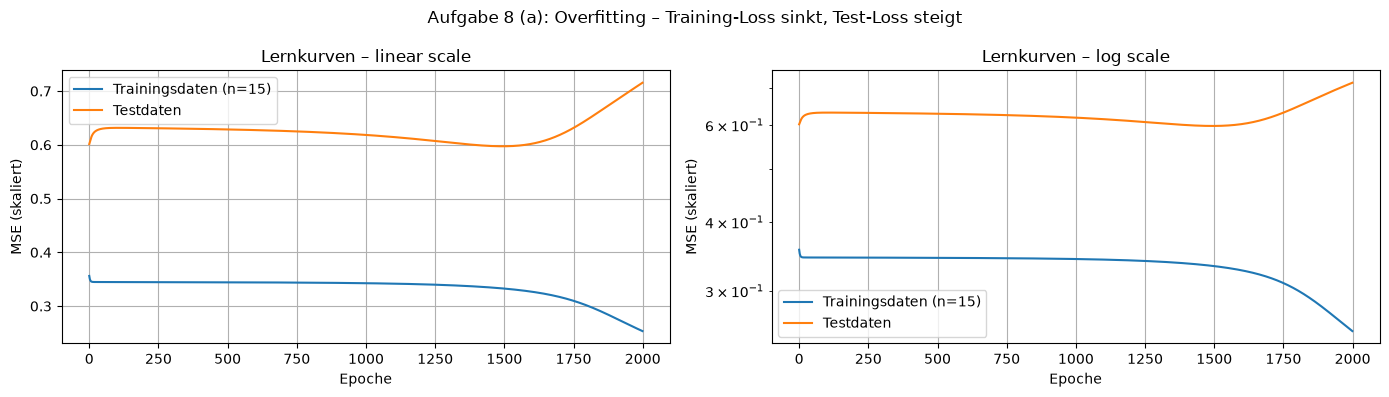

In [51]:
#| code-fold: true
#| code-summary: "Lösung anzeigen"

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt('Daten/UeberwachtesLernen/messwerte2.txt')
X = data[:, 0]
Y = data[:, 1]

N = X.shape[0]
perm = rng.permutation(N)
split = int(0.8 * N)
Xtr, Ytr = X[perm[:split]], Y[perm[:split]]
Xte, Yte = X[perm[split:]], Y[perm[split:]]

# Standardisierung
x_mean = Xtr.mean(axis=0, keepdims=True)
x_std  = Xtr.std(axis=0, keepdims=True) + 1e-8 # die + 1e-8 verhindert eine Division durch Null
y_mean = Ytr.mean(axis=0, keepdims=True)
y_std  = Ytr.std(axis=0, keepdims=True) + 1e-8

Xs_tr = ((Xtr - x_mean) / x_std).reshape(-1,1)
Xs_te = ((Xte - x_mean) / x_std).reshape(-1,1)
Ys_tr = ((Ytr - y_mean) / y_std).reshape(-1,1)
Ys_te = ((Yte - y_mean) / y_std).reshape(-1,1)

# Nur 15 zufällige Punkte als Trainingsdaten
n_small = 15
idx_small = rng.choice(len(Xs_tr), size=n_small, replace=False)
Xs_small = Xs_tr[idx_small]
Ys_small = Ys_tr[idx_small]

model_a = NN(in_dim=1, h1=20, h2=20, seed=1)
epochs_a = 2000
lr_a     = 0.05  # 

train_hist_a = []
test_hist_a  = []

for ep in range(1, epochs_a + 1):
    yhat, cache = model_a.forward(Xs_small)
    grads = model_a.backward(cache, yhat, Ys_small)
    model_a.step(grads, lr_a)

    yhat_tr, _ = model_a.forward(Xs_small)
    yhat_te, _ = model_a.forward(Xs_te)
    train_hist_a.append(mse(yhat_tr, Ys_small))
    test_hist_a.append(mse(yhat_te, Ys_te))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, scale in zip(axes, ['linear', 'log']):
    ax.plot(train_hist_a, label='Trainingsdaten (n=15)')
    ax.plot(test_hist_a,  label='Testdaten')
    ax.set_xlabel('Epoche')
    ax.set_ylabel('MSE (skaliert)')
    ax.set_title(f'Lernkurven – {scale} scale')
    ax.set_yscale(scale)
    ax.legend()
    ax.grid()
fig.suptitle('Aufgabe 8 (a): Overfitting – Training-Loss sinkt, Test-Loss steigt', fontsize=12)
fig.tight_layout()


### Aufgabe 9 (b): Early Stopping

Ergänzen Sie die Trainingsschleife aus Aufgabe (a) um **Early Stopping**: Das Training soll automatisch abbrechen, sobald der Test-Loss für 50 aufeinanderfolgende Epochen nicht mehr gesunken ist.

Speichern Sie dabei die besten Gewichte (d.h. den Zustand des Netzes mit dem niedrigsten Test-Loss) und stellen Sie diese am Ende wieder her.

*Hinweis:* Die Gewichte eines `NN`-Objekts können mit `import copy` und `copy.deepcopy(model)` gespeichert werden.

**Frage:** Bei welcher Epoche bricht das Training ab? Vergleichen Sie das Ergebnis visuell mit Aufgabe A.

In [52]:
#| code-fold: true
#| code-summary: "Bekanntes NN und Aktivierungsfunktionen anzeigen"
# Die NN-Klasse wird hier erneut definiert, damit die Aufgaben unabhängig ausführbar sind

class NN:
    def __init__(self, in_dim=1, h1=20, h2=20, seed=1):
        rng = np.random.default_rng(seed)
        # Glorot-Normal (gut für tanh)
        def glorot(fan_in, fan_out):
            std = np.sqrt(2.0 / (fan_in + fan_out))
            return rng.normal(0.0, std, size=(fan_in, fan_out))

        self.W1 = glorot(in_dim, h1); self.b1 = np.zeros((1, h1))
        self.W2 = glorot(h1, h2);     self.b2 = np.zeros((1, h2))
        self.W3 = glorot(h2, 1);      self.b3 = np.zeros((1, 1))

    # Netzwerk forwärts durchlaufen
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = tanh(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = tanh(z2)
        yhat = a2 @ self.W3 + self.b3
        cache = (X, z1, a1, z2, a2, yhat)
        return yhat, cache

    # Netzwerk rückwärts durchlaufen (fürs Training)
    def backward(self, cache, yhat, y, l2=0.0):
        X, z1, a1, z2, a2, _ = cache

        dy = mse_grad(yhat, y)

        # Layer 3
        dW3 = a2.T @ dy
        db3 = dy.sum(axis=0, keepdims=True)

        # Layer 2
        da2 = dy @ self.W3.T
        dz2 = da2 * dtanh(z2)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        # Layer 1
        da1 = dz2 @ self.W2.T
        dz1 = da1 * dtanh(z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}
        return grads

    # Update der Gewichte anhand eines Gradienten und einer Lernrate
    def step(self, grads, lr):
        self.W1 -= lr * grads["W1"]; self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]; self.b2 -= lr * grads["b2"]
        self.W3 -= lr * grads["W3"]; self.b3 -= lr * grads["b3"]


def tanh(z): 
    return np.tanh(z)

def dtanh(z):
    t = np.tanh(z)
    return 1.0 - t*t

def mse(yhat, y):
    return 0.5 * ((yhat - y) ** 2).mean()

def mse_grad(yhat, y):
    return (yhat - y) / y.shape[0]

Early Stopping nach Epoche 51 (bestes Modell: Epoche 1)


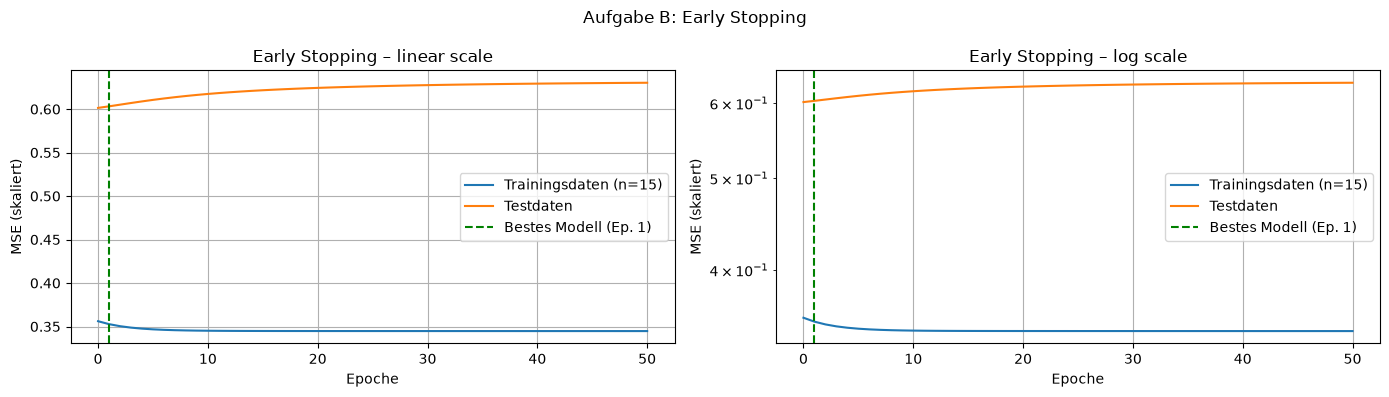

In [53]:
#| include: false
#| code-fold: true
#| code-summary: "Lösung anzeigen"

import copy

model_b   = NN(in_dim=1, h1=20, h2=20, seed=1)
epochs_b  = 2000
lr_b      = 0.05  # gleiche Lernrate wie 9(a)
patience  = 50   # Epochen ohne Verbesserung bis Abbruch

train_hist_b = []
test_hist_b  = []
best_loss  = np.inf
best_model = None
no_improve = 0
best_epoch = 0

for ep in range(1, epochs_b + 1):
    yhat, cache = model_b.forward(Xs_small)
    grads = model_b.backward(cache, yhat, Ys_small)
    model_b.step(grads, lr_b)

    yhat_tr, _ = model_b.forward(Xs_small)
    yhat_te, _ = model_b.forward(Xs_te)
    train_hist_b.append(mse(yhat_tr, Ys_small))
    test_hist_b.append(mse(yhat_te, Ys_te))

    if test_hist_b[-1] < best_loss:
        best_loss  = test_hist_b[-1]
        best_model = copy.deepcopy(model_b)
        best_epoch = ep
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f'Early Stopping nach Epoche {ep} (bestes Modell: Epoche {best_epoch})')
        break

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, scale in zip(axes, ['linear', 'log']):
    ax.plot(train_hist_b, label='Trainingsdaten (n=15)')
    ax.plot(test_hist_b,  label='Testdaten')
    ax.axvline(best_epoch, color='green', linestyle='--',
               label=f'Bestes Modell (Ep. {best_epoch})')
    ax.set_xlabel('Epoche')
    ax.set_ylabel('MSE (skaliert)')
    ax.set_title(f'Early Stopping – {scale} scale')
    ax.set_yscale(scale)
    ax.legend()
    ax.grid()
fig.suptitle('Aufgabe B: Early Stopping', fontsize=12)
fig.tight_layout()


### Aufgabe 9(c): L2-Regularisierung

In dieser Aufgabe wird die L2-Regularisierung implementiert.
Dahinter steckt folgende Idee: Dem normalen MSE-Loss wird ein Strafterm für große Gewichte hinzugefügt:

$$L_{total} = \underbrace{MSE}_{\text{normaler Loss}} + \underbrace{\frac{\lambda}{2} \sum W^2}_{\text{Strafterm}}$$

Je größer ein Gewicht, desto mehr wird die Gesamtloss erhöht — das Netz wird also bestraft, wenn es zu extreme Werte annimmt.
Effekt auf Overfitting: Das Netz kann sich keine großen, spitzen Gewichte "leisten", die nötig wären, um die 15 Trainingspunkte perfekt auswendig zu lernen. Die gelernte Kurve bleibt glatter und generalisiert besser.

Implementieren Sie im Code die L2-Regularisierung im Code bei der Definition der NN-Klasse.
Gehen Sie folgendermaßen vor:

- Definieren Sie eine Variable l2
- Addieren Sie im Code nach der Berechnung des Gradienten in folgender Weise den Strafterm:

```python
if l2 > 0.0:
    dW3 += l2 * self.W3
    dW2 += l2 * self.W2
    dW1 += l2 * self.W1
```

Anmerkung: Die Ableitung des Strafterms $\frac{\lambda}{2} \sum W^2$ ist $\lambda \cdot W$.

- Trainieren Sie das Netz aus Aufgabe (a) (2000 Epochen, 15 Punkte) mit verschiedenen Werten:
    - l2 = 0.0
    - l2 = 0.001
    - l2 = 0.003
    - l2 = 0.01
- Plotten Sie für alle vier Werte die Lernkurven nebeneinander.

Welcher `l2`-Wert liefert den besten Test-Loss? 

Probieren Sie auch mehr als 15 Datenpunkte aus. 

In [66]:
#| include: false
#| code-fold: true
#| code-summary: "Bekanntes NN und Aktivierungsfunktionen anzeigen"
# Die NN-Klasse wird hier erneut definiert, damit die Aufgaben unabhängig ausführbar sind

class NN:
    def __init__(self, in_dim=1, h1=20, h2=20, seed=1):
        rng = np.random.default_rng(seed)
        # Glorot-Normal (gut für tanh)
        def glorot(fan_in, fan_out):
            std = np.sqrt(2.0 / (fan_in + fan_out))
            return rng.normal(0.0, std, size=(fan_in, fan_out))

        self.W1 = glorot(in_dim, h1); self.b1 = np.zeros((1, h1))
        self.W2 = glorot(h1, h2);     self.b2 = np.zeros((1, h2))
        self.W3 = glorot(h2, 1);      self.b3 = np.zeros((1, 1))

    # Netzwerk forwärts durchlaufen
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = tanh(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = tanh(z2)
        yhat = a2 @ self.W3 + self.b3
        cache = (X, z1, a1, z2, a2, yhat)
        return yhat, cache

    # Netzwerk rückwärts durchlaufen (fürs Training)
    def backward(self, cache, yhat, y, l2=0.0):
        X, z1, a1, z2, a2, _ = cache

        dy = mse_grad(yhat, y)

        # Layer 3
        dW3 = a2.T @ dy
        db3 = dy.sum(axis=0, keepdims=True)

        # Layer 2
        da2 = dy @ self.W3.T
        dz2 = da2 * dtanh(z2)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        # Layer 1
        da1 = dz2 @ self.W2.T
        dz1 = da1 * dtanh(z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        # L2 (optional) auf Gewichte
        if l2 > 0.0:
            dW3 += l2 * self.W3
            dW2 += l2 * self.W2
            dW1 += l2 * self.W1

        grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}
        return grads

    # Update der Gewichte anhand eines Gradienten und einer Lernrate
    def step(self, grads, lr):
        self.W1 -= lr * grads["W1"]; self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]; self.b2 -= lr * grads["b2"]
        self.W3 -= lr * grads["W3"]; self.b3 -= lr * grads["b3"]


def tanh(z): 
    return np.tanh(z)

def dtanh(z):
    t = np.tanh(z)
    return 1.0 - t*t

def mse(yhat, y):
    return 0.5 * ((yhat - y) ** 2).mean()

def mse_grad(yhat, y):
    return (yhat - y) / y.shape[0]


In [55]:
#| include: false
#| code-fold: true

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

import matplotlib.pyplot as plt
import numpy as np

data = np.loadtxt('Daten/UeberwachtesLernen/messwerte2.txt')
X = data[:, 0]
Y = data[:, 1]

N = X.shape[0]
perm = rng.permutation(N)
split = int(0.8 * N)
Xtr, Ytr = X[perm[:split]], Y[perm[:split]]
Xte, Yte = X[perm[split:]], Y[perm[split:]]

# Standardisierung
x_mean = Xtr.mean(axis=0, keepdims=True)
x_std  = Xtr.std(axis=0, keepdims=True) + 1e-8 # die + 1e-8 verhindert eine Division durch Null
y_mean = Ytr.mean(axis=0, keepdims=True)
y_std  = Ytr.std(axis=0, keepdims=True) + 1e-8

Xs_tr = ((Xtr - x_mean) / x_std).reshape(-1,1)
Xs_te = ((Xte - x_mean) / x_std).reshape(-1,1)
Ys_tr = ((Ytr - y_mean) / y_std).reshape(-1,1)
Ys_te = ((Yte - y_mean) / y_std).reshape(-1,1)

# Nur 15 zufällige Punkte als Trainingsdaten
n_small = 50
idx_small = rng.choice(len(Xs_tr), size=n_small, replace=False)
Xs_small = Xs_tr[idx_small]
Ys_small = Ys_tr[idx_small]

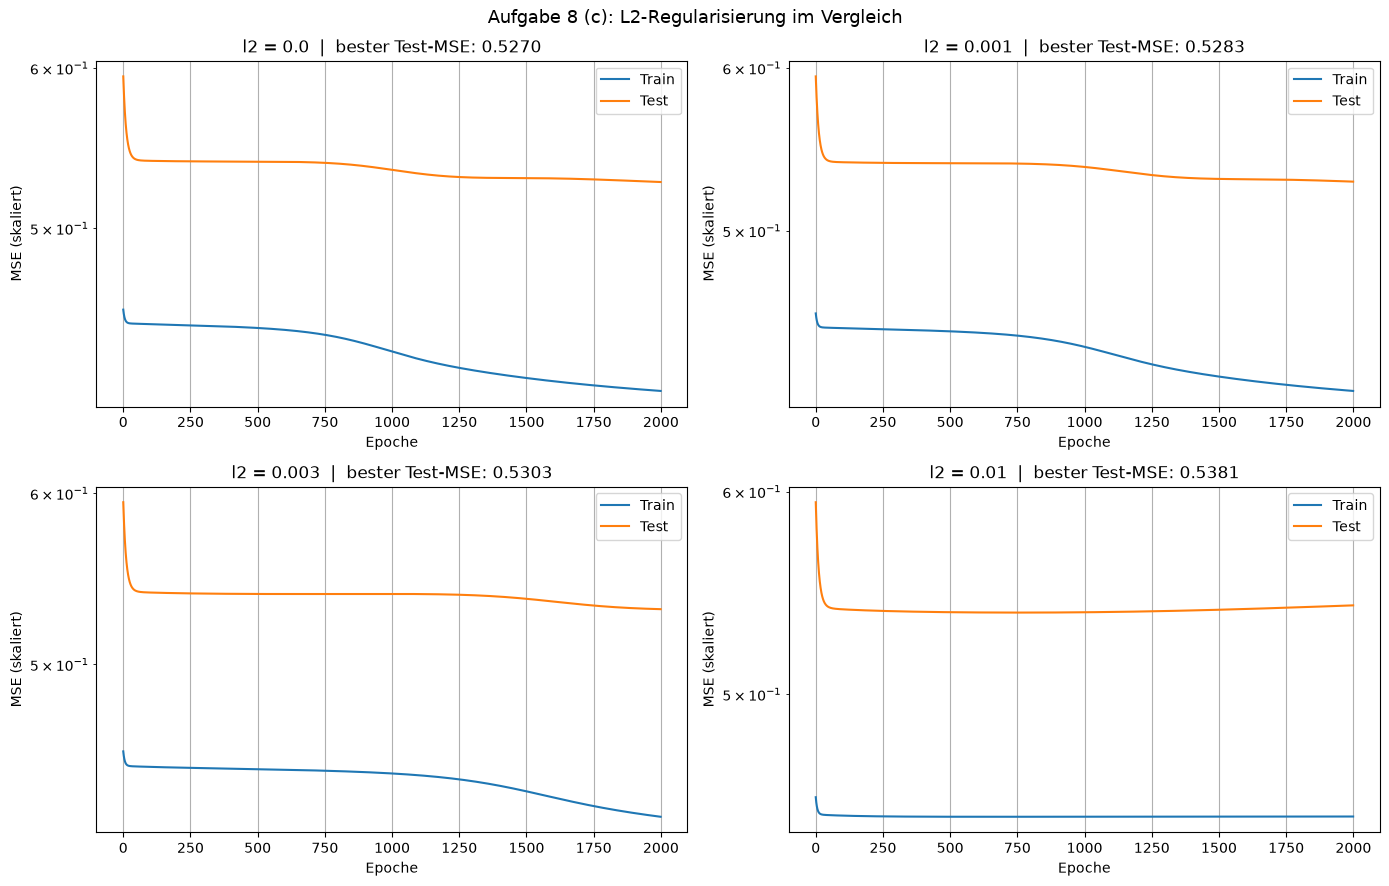

In [56]:
#| include: false
#| code-fold: true
#| code-summary: "Lösung anzeigen"

l2_values = [0.0, 0.001, 0.003, 0.01]
epochs_c  = 2000
lr_c      = 0.05   # wie 8(a) – gleiche Ausgangsbedingungen

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Aufgabe 8 (c): L2-Regularisierung im Vergleich', fontsize=13)

for ax, l2_val in zip(axes.flat, l2_values):
    model_c = NN(in_dim=1, h1=20, h2=20, seed=1)
    tr_hist, te_hist = [], []

    for ep in range(1, epochs_c + 1):
        yhat, cache = model_c.forward(Xs_small)
        grads = model_c.backward(cache, yhat, Ys_small, l2=l2_val)
        model_c.step(grads, lr_c)

        yhat_tr, _ = model_c.forward(Xs_small)
        yhat_te, _ = model_c.forward(Xs_te)
        tr_hist.append(mse(yhat_tr, Ys_small))
        te_hist.append(mse(yhat_te, Ys_te))

    best_te = min(te_hist)
    ax.plot(tr_hist, label='Train')
    ax.plot(te_hist, label='Test')
    ax.set_title(f'l2 = {l2_val}  |  bester Test-MSE: {best_te:.4f}')
    ax.set_xlabel('Epoche')
    ax.set_ylabel('MSE (skaliert)')
    ax.set_yscale('log')
    ax.legend()
    ax.grid()

fig.tight_layout()


### Aufgabe 9 (d): Dropout

Dropout ist eine weitere Regularisierungstechnik: Während des Trainings werden Aktivierungen der verdeckten Schichten zufällig auf Null gesetzt.

Implementieren Sie eine Unterklasse `NNDropout(NN)`, die **Inverted Dropout** unterstützt:
- **Training** (`training=True`): Jedes Neuron wird mit Wahrscheinlichkeit `p` auf 0 gesetzt. Die verbleibenden Aktivierungen werden durch `(1 - p)` dividiert, damit der Erwartungswert der Ausgabe erhalten bleibt.
- **Testen** (`training=False`): Kein Dropout – alle Neuronen sind aktiv, keine Skalierung nötig.

Trainieren Sie das Netz aus Aufgabe (a) (2000 Epochen, 15 Punkte, `lr=0.05`) mit drei Dropout-Raten:

- 0.0
- 0.2
- 0.5

Plotten Sie die Lernkurven (log-Skala) für alle drei Werte nebeneinander.

Was sehen Sie?

In [57]:
#| code-fold: true
#| code-summary: "Um Dropout erweitertes Netz"


class NNDropout(NN):
    def __init__(self, in_dim=1, h1=20, h2=20, seed=1, dropout_rate=0.0):
        super().__init__(in_dim, h1, h2, seed)
        self.dropout_rate = dropout_rate
        self._drng = np.random.default_rng(seed + 999)

    def forward(self, X, training=True):
        z1 = X @ self.W1 + self.b1
        a1 = tanh(z1)
        if training and self.dropout_rate > 0:
            mask1 = (self._drng.random(a1.shape) > self.dropout_rate) / (1 - self.dropout_rate)
            a1 = a1 * mask1
        else:
            mask1 = np.ones_like(a1)

        z2 = a1 @ self.W2 + self.b2
        a2 = tanh(z2)
        if training and self.dropout_rate > 0:
            mask2 = (self._drng.random(a2.shape) > self.dropout_rate) / (1 - self.dropout_rate)
            a2 = a2 * mask2
        else:
            mask2 = np.ones_like(a2)

        yhat = a2 @ self.W3 + self.b3
        return yhat, (X, z1, a1, z2, a2, yhat, mask1, mask2)

    def backward(self, cache, yhat, y, l2=0.0):
        X, z1, a1, z2, a2, _, mask1, mask2 = cache
        dy = mse_grad(yhat, y)

        dW3 = a2.T @ dy
        db3 = dy.sum(axis=0, keepdims=True)

        da2 = (dy @ self.W3.T) * mask2
        dz2 = da2 * dtanh(z2)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        da1 = (dz2 @ self.W2.T) * mask1
        dz1 = da1 * dtanh(z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        if l2 > 0.0:
            dW3 += l2 * self.W3
            dW2 += l2 * self.W2
            dW1 += l2 * self.W1

        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}

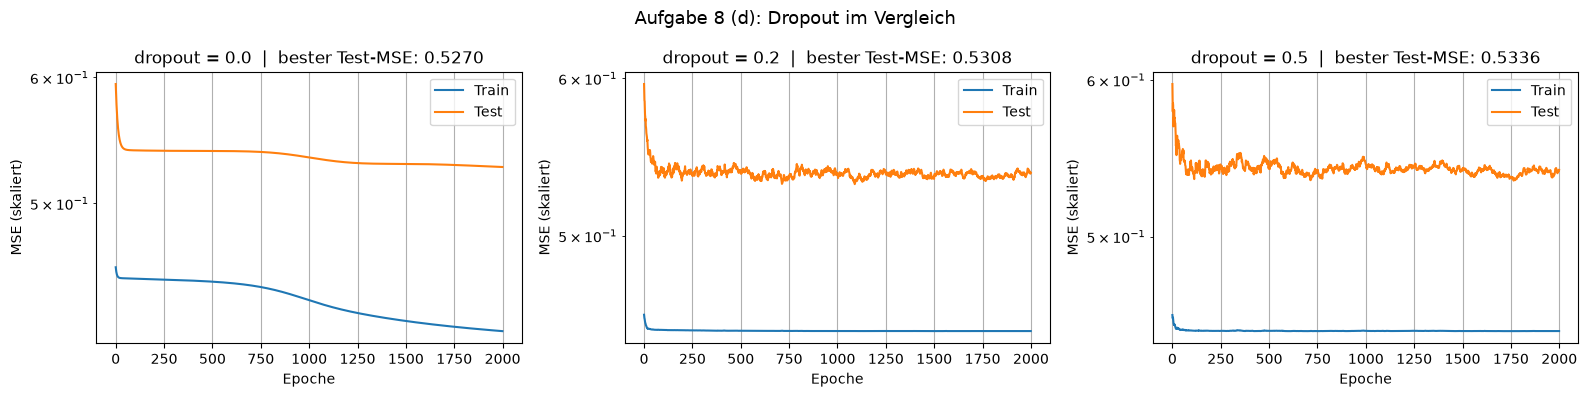

In [58]:
#| code-fold: true
#| code-summary: "Lösung anzeigen"

dropout_values = [0.0, 0.2, 0.5]
epochs_d = 2000
lr_d     = 0.05

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Aufgabe 8 (d): Dropout im Vergleich', fontsize=13)

for ax, p in zip(axes, dropout_values):
    model_d = NNDropout(in_dim=1, h1=20, h2=20, seed=1, dropout_rate=p)
    tr_hist, te_hist = [], []

    for ep in range(1, epochs_d + 1):
        yhat, cache = model_d.forward(Xs_small, training=True)
        grads = model_d.backward(cache, yhat, Ys_small)
        model_d.step(grads, lr_d)

        yhat_tr, _ = model_d.forward(Xs_small, training=False)
        yhat_te, _ = model_d.forward(Xs_te,    training=False)
        tr_hist.append(mse(yhat_tr, Ys_small))
        te_hist.append(mse(yhat_te, Ys_te))

    best_te = min(te_hist)
    ax.plot(tr_hist, label='Train')
    ax.plot(te_hist, label='Test')
    ax.set_title(f'dropout = {p}  |  bester Test-MSE: {best_te:.4f}')
    ax.set_xlabel('Epoche')
    ax.set_ylabel('MSE (skaliert)')
    ax.set_yscale('log')
    ax.legend()
    ax.grid()

fig.tight_layout()